# The DREAMS K-Complex Database

Data were acquired in a sleep laboratory of a belgium hospital using a digital 32-channel polygraph (BrainnetTM System of MEDATEC, Brussels, Belgium). They consist of 10 polysomnographic recordings coming from healthy subjects. Two EOG channels (P8-A1, P18-A1), three EEG channels (CZ-A1 or C3-A1, FP1-A1 and O1-A1) and one submental EMG channel were recorded. The standard European Data Format (EDF) was used for storing. The sampling frequency was 200Hz. A segment of 30 minutes of the central EEG channel was extracted from each whole-night recording for K-complexes scoring. These excerpts were given independently to two experts with the following recommendation regarding this annotation:
- K-complex must be a biphasic wave composed of a first negative sharp wave immediately followed by a slower positive component.
- It can occur isolated or by pair.
- It can be associated with spindles (before, after, or on it).
- Its duration should be at least 0.5s and no more than 1.5s.
- Its amplitude should be at least twice as high as the EEG background.
- The amplitude of the negative component should be at least 50% of the positive amplitude component.
- The minimum interval between successive K-complexes in slow wave sleep should be greater than 2s.
The corresponding whole night recordings were also previously scored in sleep stages according to the Rechtschaffen and Kales criteria, but no note of these stages quotations was given to the scorers. Unfortunately, the second expert has only annotated the first five excerpts.

Six files are available per excerpt (except for the five last excerpts, for which visual scoring 2 is absent):

* _excerpt.edf:_ corresponds to the polysomnographic recording in the European Data Format (EDF)
* _excerpt.txt:_ is a textual file containing, in first line, the name of the signal extracted (the central EEG) and then 1 column with the values (amplitudes in microvolt) of its samples. The number of samples depends on the sampling rate corresponding to the excerpt (see Database description)
* _Automatic_detection_excerpt.txt:_ is a textual file containing, in first line, the name of the detection and then 2 columns of numerical values. The first column contains time instants (in second) corresponding to the beginnings of the automatically detected micro-events (from the beginning of the excerpt), and the second one contains their durations (in second).
* _Visual_scoring1_excerpt.txt:_ is a textual file containing, in the first line, the name of the detection and then, 2 columns of numerical values. The first column contains time instants (in second) corresponding to the beginnings of the micro-events scored by the expert 1 (from the beginning of the excerpt), and the second one contains their durations (in second).
* _Visual_scoring2_excerpt.txt:_ is a textual file containing, in first line, the name of the detection and then 2 columns of numerical values. The first column contains time instants (in second) corresponding to the beginnings of the micro-events scored by the expert 2 (from the beginning of the excerpt), and the second one contains their durations (in second).
* _Hypnogram_excerpt.txt:_ is a textual file containing, in first line, the name "[hypnogram]" followed by one column of integer. These numerical values correspond to the sleep stage (one value per 5 sec) annotated by the expert according to the Rechtschaffen and Kales criteria.

## Set Up

In [1]:
import os
import sys

current_dir = os.getcwd()
new_root = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm'
sys.path.insert(0, new_root)

In [2]:
import mne
import configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import * #load_configuration_parameters, load_file
from src.data.preprocess import *
from src.base.localizator import * #get_candidates
from src.features.build_features import *
from src.features.build_features_utils import *

import os
from collections import Counter
import random
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold, StratifiedShuffleSplit, GroupKFold
from sklearn import svm
from sklearn.metrics import ConfusionMatrixDisplay

## Correct sleep stages epoch

In [ ]:
# def convert_5s_to_30s_epochs(input_path, output_path):
#     # Read the 5s-scored sleep stages
#     with open(input_path, 'r') as f:
#         lines = f.readlines()

#     # Clean and convert to integers (or strings, depending on your format)
#     stages = [line.strip() for line in lines if line.strip() != '']

#     # Chunk into 30s epochs (6 values per epoch)
#     new_epochs = []
#     for i in range(0, len(stages), 6):
#         chunk = stages[i:i+6]
#         # if len(chunk) < 6:
#         #     continue  # Skip incomplete final chunk
#         # Majority vote
#         most_common = Counter(chunk).most_common(1)[0][0]
#         new_epochs.append(most_common)

#     # Write the 30s epoch version to output file
#     with open(output_path, 'w') as f:
#         for stage in new_epochs:
#             f.write(f"{stage}\n")

# # Example for batch processing multiple files
# def batch_convert_hypnograms(folder_path):
#     for filename in os.listdir(folder_path):
#         if filename.startswith("Hypnogram_excerpt") and filename.endswith(".txt") and "_30s_epoch" not in filename:
#             input_file = os.path.join(folder_path, filename)
#             output_file = os.path.join(folder_path, filename.replace(".txt", "_30s_epoch.txt"))
#             convert_5s_to_30s_epochs(input_file, output_file)
#             print(f"Processed {filename} → {os.path.basename(output_file)}")

# # Usage
# folder = r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm"
# batch_convert_hypnograms(folder)


## Localizator

In [3]:
def set_sleep_stages_per_sample(signal, path_scoring: str, epoch_duration: int =30, sfreq: int =250):
    """
    Set sleep stages per sample in data
    """
    stages = np.loadtxt(path_scoring, skiprows=1)
    assert len(stages) == len(signal)//(epoch_duration*sfreq), "File with sleep stages annotations has a different amount of annotations comparing to the recording length"
    
    stages_per_sample = np.repeat(stages, epoch_duration*sfreq, axis=0) 

    return stages_per_sample

def get_candidates(signal:np.ndarray, path_scoring:str , sfreq: int, window_length: int = 2, stages_allowed:list =[2.0], step:float = 0.1) :
    """
    Detect KC candidates
    """
    stages_per_sample = set_sleep_stages_per_sample(signal, path_scoring, epoch_duration=30, sfreq=sfreq)    
    signal = signal[:len(stages_per_sample)]
    pos_candidate = []
    pos = 0
    while pos < len(signal):
        if stages_per_sample[pos] in stages_allowed:
            # print('Ok stage')
            window = signal[pos:pos+int(window_length*sfreq)]
            if check_if_meet_main_conditions(window, sfreq):
                # print('Ok meet main conditions')
                try:
                    window, idx_start, _, _, _, idx_end, new_pos = detect_points_of_event(window, sfreq, signal, pos, window_length=3)
                except AssertionError: # Could not find the points of the event correctly
                    # print('Could not find the points of the event correctly')
                    # print('Prev pos', pos)
                    pos += int(window_length/2*sfreq)
                    # print('Now pos', pos)
                    continue
                # print('FOUND CANDIDATE')
                if len(pos_candidate) >= 1:
                    if (new_pos + idx_start) <= (pos_candidate[-1][0]+pos_candidate[-1][1])*sfreq:
                        # print('Changed new_pos')
                        new_pos = int((pos_candidate[-1][0]+pos_candidate[-1][1])*sfreq + 1)

                if new_pos + idx_end < len(signal):
                    pos_candidate.append([(new_pos + idx_start)/sfreq, (idx_end-idx_start)/sfreq]) #[onset, duration]
                # print('KC from', new_pos + idx_start, 'to', new_pos + idx_end)
                # print('Prev pos', pos)
                pos = new_pos + idx_end + 1
                # print('Now pos', pos)
            else:
                # print('Do not meet main conditions')
                # print('Prev pos', pos)
                pos += int(step*sfreq)
                # print('Now pos', pos)
        else:
            # print('Wrong stage')
            # print('Prev pos', pos)
            pos += int(30*sfreq)
            # print('Now pos', pos)
    
    predicted = []
    for p in pos_candidate:
        predicted.append([p[0],p[1]])
        
    return predicted

def load_expert_annotations(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # Skip header line
    annotations = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 2:
            continue
        start, duration = map(float, parts[:2])
        end = start + duration
        annotations.append((start, end))
    return annotations

def load_stage2_epochs(hypnogram_path):
    with open(hypnogram_path, 'r') as f:
        stages = [line.strip() for line in f.readlines()]
    return stages

def filter_annotations_by_stage2(filepath, stage2_epochs):
    annotations = []
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # Skip header
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            start, duration = map(float, parts[:2])
            end = start + duration
            midpoint = (start + end) / 2
            epoch_idx = int(midpoint // 30)
            if epoch_idx < len(stage2_epochs) and stage2_epochs[epoch_idx] == "2":
                annotations.append((start, end))
    return annotations

def is_candidate_overlapping(candidate, annotations):
    c_start, c_dur = candidate
    c_end = c_start + c_dur
    for a_start, a_end in annotations:
        if a_start <= c_end and a_end >= c_start:
            return True
    return False

def label_candidates_and_count_matches(candidates, expert1_path, expert2_path="", hypnogram_path="", subject_num=1):
    stage2_epochs = load_stage2_epochs(hypnogram_path)

    expert1_annotations = filter_annotations_by_stage2(expert1_path, stage2_epochs)
    if subject_num <= 5:
        expert2_annotations = filter_annotations_by_stage2(expert2_path, stage2_epochs)

    labels = []
    matched_expert1 = set()
    if subject_num <= 5:
        matched_expert2 = set()

    for i, candidate in enumerate(candidates):
        in_exp1 = is_candidate_overlapping(candidate, expert1_annotations)
        in_exp2 = False
        if subject_num <= 5:
            in_exp2 = is_candidate_overlapping(candidate, expert2_annotations)

        if in_exp1 and in_exp2:
            labels.append("both")
        elif in_exp1:
            labels.append("expert1")
        elif in_exp2:
            labels.append("expert2")
        else:
            labels.append("none")

        # Track which expert annotations were matched by any candidate
        for idx, (a_start, a_end) in enumerate(expert1_annotations):
            if a_start <= candidate[0] + candidate[1] and a_end >= candidate[0]:
                matched_expert1.add(idx)
        if subject_num <=5:
            for idx, (a_start, a_end) in enumerate(expert2_annotations):
                if a_start <= candidate[0] + candidate[1] and a_end >= candidate[0]:
                    matched_expert2.add(idx)

    # Final counts
    total_exp1 = len(expert1_annotations)
    num_matched_exp1 = len(matched_expert1)
    if subject_num <=5:
        total_exp2 = len(expert2_annotations)
        num_matched_exp2 = len(matched_expert2)
    
        return labels, {
            "expert1_total": total_exp1,
            "expert1_matched": num_matched_exp1,
            "expert2_total": total_exp2,
            "expert2_matched": num_matched_exp2
        }, expert1_annotations, expert2_annotations
    
    else:
        return labels, {
            "expert1_total": total_exp1,
            "expert1_matched": num_matched_exp1}, expert1_annotations, []
    
def get_KC_event(onset_duration, signal, sfreq, window=2, timelocked2='center', return_start_of_event=False):
    """
    Get KC event
    """
    onset, duration = onset_duration
    if timelocked2 == 'center':
        start = int(onset*sfreq)
        end = int(start + duration*sfreq)
        KC_labeled = signal[start:end]
        center, maxi, mini = get_center_maxi_mini(KC_labeled)
        center_in_signal = int(start + center)
        mini_to_center = abs(mini-center)
        maxi_to_center = abs(maxi-center)
        new_start = center_in_signal-int(window*sfreq/2)
        KC = signal[new_start:center_in_signal+int(window*sfreq/2)]
    elif timelocked2 == 'min':
        start = int(onset*sfreq)
        end = int(start + duration*sfreq)
        KC_labeled = signal[start:end]
        center, maxi, mini = get_center_maxi_mini(KC_labeled)
        center_in_signal = start + mini
        mini_to_center = 0
        maxi_to_center = abs(maxi-mini)
        new_start = center_in_signal-int(window*sfreq/2)
        #KC = signal[new_start:center_in_signal-int(window*sfreq/2)]
        KC = signal[new_start:new_start+int(window*sfreq)]

    if return_start_of_event:
        return new_start
    else:
        return KC, maxi_to_center, mini_to_center
    
def is_there_any_candidates_overlapping(candidates):
    #[onset, duration]
    for cand1, cand2 in zip(candidates[:-1],candidates[1:]):
        onset1, duration1 = cand1[0], cand1[1]
        onset2, duration2 = cand2[0], cand2[1]
        if onset2 < onset1 + duration1:
            print(onset1, duration1)
            print(onset2, duration2)
            return True
    
    return False

In [ ]:
expert = 'any_both' #expert1, expert2, any_both, both_same_time
window = 2
fs = 200

if expert == 'expert1':
    list_of_experts = ['both', 'expert1']
    subjects = [i+1 for i in range(10)]
elif expert == 'expert2':
    list_of_experts = ['both', 'expert2']
    subjects = [i+1 for i in range(5)]
elif expert == 'any_both':
    list_of_experts = ['both', 'expert2', 'expert1']
    subjects = [i+1 for i in range(5)]
elif expert == 'both_same_time':
    list_of_experts = ['both']
    subjects = [i+1 for i in range(5)]

df_overall = pd.DataFrame(data=[], columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject", "Label"])

for subject_num in subjects:
    print('Analyzing subject',subject_num, '...')

    # Read annotation from experts
    annot_file1 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring1_excerpt'+str(subject_num)+'.txt'
    data = np.loadtxt(annot_file1, skiprows=1)
    event_times1, durations1 = data[:, 0], data[:, 1]

    if subject_num <= 5: #Specialist 2 only annotate from subj 1 to 5
        annot_file2 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring2_excerpt'+str(subject_num)+'.txt'
        data = np.loadtxt(annot_file2, skiprows=1)
        event_times2, durations2 = data[:, 0], data[:, 1]
    else:
        event_times2, durations2 = np.array([]), np.array([]) 
    
    # Read annotations from DREAMS automatic algorithm
    dreams_detection_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Automatic_detection_excerpt'+str(subject_num)+'.txt'
    data = np.loadtxt(dreams_detection_file, skiprows=1)
    predicted_event_times, predicted_durations = data[:, 0], data[:, 1]

    # Read sleep scoring file
    scoring_file_30s = r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Hypnogram_excerpt"+str(subject_num)+"_30s_epoch.txt"
    with open(scoring_file_30s, 'r') as f:
        lines = f.readlines()[1:]  # skip first line
        stages = np.array([int(line.strip()) for line in lines])
    
    # Identify epochs with stage 2
    stage_2_indices = np.where(stages == 2)[0]

    # Assume each epoch is 30 seconds long
    epoch_duration = 30  # seconds
    time_stage_2 = stage_2_indices * epoch_duration

    # Create binary indicator for plotting
    indicator = np.zeros_like(stages, dtype=int)
    indicator[stage_2_indices] = 1

    # Read edf file
    edf_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt'+ str(subject_num) +'.edf'
    raw = mne.io.read_raw_edf(edf_file, preload=True)
    channels = raw.info['ch_names']

    # Filter only channel to use
    raw_filtered = raw.copy().filter(l_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][0], h_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][1], picks='CZ-A1')

    # Get channel to detect candidates and sample frequency
    x = raw_filtered.get_data(picks='CZ-A1').flatten()
    fs = raw.info['sfreq']

    # LOCALIZATOR - Get candidates
    candidates = get_candidates(signal=x, path_scoring=scoring_file_30s , sfreq=fs, window_length=2)

    if is_there_any_candidates_overlapping(candidates):
        print('CHECK OVERLAP!')

    labels, match_stats, expert1_annotations, expert2_annotations = label_candidates_and_count_matches(candidates,
                                                                                                        annot_file1,
                                                                                                        annot_file2,
                                                                                                        scoring_file_30s,
                                                                                                        subject_num)

    events = []
    for cand, lab in zip(candidates, labels):
        #print(cand)
        cand_event = get_KC_event(cand, x, sfreq=fs, window=2, timelocked2='min')[0].tolist()
        if lab in list_of_experts:
            cand_lab = 'KC'
        else:
            cand_lab = 'noKC'
        events.append(cand_event + [subject_num, cand_lab])
    
    #List of events
    df_events = pd.DataFrame(data=events, columns=[f"sample{i+1}" for i in range(int(window*fs))]+["Subject","Label"])
    df_overall = pd.concat([df_overall, df_events],  ignore_index=True)


#Deleting NaN rows as they were candidates out of S2
df_overall.drop(df_overall[df_overall['Label'].isna()].index, inplace=True)

df_overall.head()

Analyzing subject 1 ...
Extracting EDF parameters from C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 359999  =      0.000 ...  1799.995 secs...


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP, POS
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Physical range is not defined in following channels:
PCPAP, POS
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True)
c:\Users\ayvazquez\aylin\KC_detection_algorithm\.venv\lib\site-packages\mne\io\edf\edf.py:786: RuntimeWarning: All-NaN axis encountered
  value = np.nanmax([_prefilter_float(x) for x in values])
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw =

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.16 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.16
- Lower transition bandwidth: 0.16 Hz (-6 dB cutoff frequency: 0.08 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 4125 samples (20.625 s)

Analyzing subject 2 ...
Extracting EDF parameters from C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 359999  =      0.000 ...  1799.995 secs...
Filtering a subs

C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_overall = pd.concat([df_overall, df_events],  ignore_index=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored

Setting up band-pass filter from 0.16 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.16
- Lower transition bandwidth: 0.16 Hz (-6 dB cutoff frequency: 0.08 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 4125 samples (20.625 s)

Analyzing subject 3 ...
Extracting EDF parameters from C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt3.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 359999  =      0.000 ...  1799.995 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.


...

C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.16 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.16
- Lower transition bandwidth: 0.16 Hz (-6 dB cutoff frequency: 0.08 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 4125 samples (20.625 s)

Analyzing subject 5 ...
Extracting EDF parameters from C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt5.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 359999  =      0.000 ...  1799.995 secs...


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_13588\454819028.py:59: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True)


Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.16 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.16
- Lower transition bandwidth: 0.16 Hz (-6 dB cutoff frequency: 0.08 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 4125 samples (20.625 s)



,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9,sample10,...,sample393,sample394,sample395,sample396,sample397,sample398,sample399,sample400,Subject,Label
0,1.343558,2.864278,4.073647,4.101170,2.873943,1.106661,-0.437328,-1.566734,-2.596249,-3.848337,...,2.706586,1.832896,0.571184,-1.333167,-3.419622,-4.997128,-5.792914,-6.153081,1.0,noKC
1,4.271639,3.890359,3.338282,2.351901,0.680670,-2.118339,-6.627057,-13.062534,-20.782365,-28.429818,...,-6.505862,-3.170469,3.290380,11.692288,20.104859,26.201948,28.054674,25.110567,1.0,noKC
2,1.295060,4.531862,6.313874,6.316516,5.268262,4.680296,5.862394,9.026707,13.227947,17.095181,...,37.822800,35.542495,31.923223,28.217103,25.707586,24.784656,24.756899,24.580020,1.0,noKC
3,-37.889934,-29.709333,-22.461825,-16.480097,-11.717621,-7.842337,-4.466249,-1.473871,0.749922,1.388802,...,-44.908884,-55.192881,-63.778206,-70.302993,-74.491113,-75.954687,-74.592338,-71.069119,1.0,noKC
4,-4.870846,-5.161826,-1.481119,4.818023,11.769031,17.714975,21.844884,24.255572,25.555165,26.208368,...,-7.635504,-9.271731,-11.740449,-15.221263,-18.851254,-21.341408,-22.317833,-22.941484,1.0,noKC


### Localizator performance

In [5]:
def count_shared_expert_events_with_candidates(expert1_annotations, expert2_annotations, candidates):
    shared_events = []

    # Step 1: Find overlapping annotations between experts
    for i, (start1, end1) in enumerate(expert1_annotations):
        for j, (start2, end2) in enumerate(expert2_annotations):
            if start1 <= end2 and end1 >= start2:
                # Create a union event from overlapping annotations
                shared_start = min(start1, start2)
                shared_end = max(end1, end2)
                shared_events.append((shared_start, shared_end))
                break  # assuming each expert1 event matches at most one from expert2

    # Step 2: Count shared events that are also candidates
    matched_by_candidates = 0
    for s_start, s_end in shared_events:
        for c_start, c_dur in candidates:
            c_end = c_start + c_dur
            if s_start <= c_end and s_end >= c_start:
                matched_by_candidates += 1
                break  # One match is enough

    return {
        "shared_expert_events": len(shared_events),
        "shared_events_matched_by_candidates": matched_by_candidates
    }

In [ ]:
mne.set_log_level('CRITICAL')

for subject_num in subjects:
    print(f'----------------------- SUBJECT {subject_num} -----------------------')
    # Read annotation from experts
    annot_file1 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring1_excerpt'+str(subject_num)+'.txt'
    data = np.loadtxt(annot_file1, skiprows=1)
    event_times1, durations1 = data[:, 0], data[:, 1]

    if subject_num <= 5: #Specialist 2 only annotate from subj 1 to 5
        annot_file2 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring2_excerpt'+str(subject_num)+'.txt'
        data = np.loadtxt(annot_file2, skiprows=1)
        event_times2, durations2 = data[:, 0], data[:, 1]
    else:
        event_times2, durations2 = np.array([]), np.array([]) 

    # Read annotations from DREAMS automatic algorithm
    dreams_detection_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Automatic_detection_excerpt'+str(subject_num)+'.txt'
    data = np.loadtxt(dreams_detection_file, skiprows=1)
    predicted_event_times, predicted_durations = data[:, 0], data[:, 1]

    # Read sleep scoring file
    scoring_file_30s = r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Hypnogram_excerpt"+str(subject_num)+"_30s_epoch.txt"
    with open(scoring_file_30s, 'r') as f:
        lines = f.readlines()[1:]  # skip first line
        stages = np.array([int(line.strip()) for line in lines])

    # Identify epochs with stage 2
    stage_2_indices = np.where(stages == 2)[0]

    # Assume each epoch is 30 seconds long
    epoch_duration = 30  # seconds
    time_stage_2 = stage_2_indices * epoch_duration

    # Create binary indicator for plotting
    indicator = np.zeros_like(stages, dtype=int)
    indicator[stage_2_indices] = 1

    # Read edf file
    edf_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt'+ str(subject_num) +'.edf'
    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
    channels = raw.info['ch_names']

    # Filter only channel to use
    raw_filtered = raw.copy().filter(l_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][0], h_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][1], picks='CZ-A1', verbose=False)

    # Get channel to detect candidates and sample frequency
    x = raw_filtered.get_data(picks='CZ-A1').flatten()
    fs = raw.info['sfreq']

    # LOCALIZATOR - Get candidates
    candidates = get_candidates(signal=x, path_scoring=scoring_file_30s , sfreq=fs, window_length=2)

    labels, match_stats, expert1_annotations, expert2_annotations = label_candidates_and_count_matches(candidates,
                                                                                                        annot_file1,
                                                                                                        annot_file2,
                                                                                                        scoring_file_30s,
                                                                                                        subject_num)

    events = []
    for cand, lab in zip(candidates, labels):
        cand_event = get_KC_event(cand, x, sfreq=fs, window=2, timelocked2='center')[0].tolist()
        if lab in ['both', expert]:
            cand_lab = 1
        else:
            cand_lab = 0
        events.append(cand_event + [subject_num, cand_lab])

    print('Events labeled by expert 1 found by localizator:', round(match_stats['expert1_matched']/match_stats['expert1_total']*100,2),r'%', f"({match_stats['expert1_matched']} out of {match_stats['expert1_total']})")
    if subject_num<=5:
        print('Events labeled by expert 2 found by localizator:', round(match_stats['expert2_matched']/match_stats['expert2_total']*100,2),r'%', f"({match_stats['expert2_matched']} out of {match_stats['expert2_total']})")

    print("Total annotations by expert 1:", len(load_expert_annotations(annot_file1)))
    print("Annotations in S2 by expert 1:", len(expert1_annotations))

    if subject_num <=5:
        print("Total annotations by expert 2:", len(load_expert_annotations(annot_file2)))
        print("Annotations in S2 by expert 2:", len(expert2_annotations))

        result = count_shared_expert_events_with_candidates(
            expert1_annotations,
            expert2_annotations,
            candidates
        )
        print('Expert 1 and expert 2 labeled', result['shared_expert_events'], 'same events, of which',result['shared_events_matched_by_candidates'], 'where found by localizator.')
    else:
        print('Expert 2 did not labeled this subject files')

    print('Candidates found by localizator:', len(candidates))
    print(f"Positive cases marked by expert 1: {len([i for i in labels if i in ['both', 'expert1']])}")
    print(f"Positive cases marked by expert 2: {len([i for i in labels if i in ['both', 'expert2']])}")
    print(f"Positive cases marked by both experts (any case): {len([i for i in labels if i in ['expert2', 'expert1', 'both']])}")
    print(f'Mismatchings:', len([i for i in labels if i in ['expert2', 'expert1']]))
    print(f"Positive cases marked by both experts (both at same time): {len([i for i in labels if i in ['both']])}")
    print()
    print()

----------------------- SUBJECT 1 -----------------------


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP, POS
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Physical range is not defined in following channels:
PCPAP, POS
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
c:\Users\ayvazquez\aylin\KC_detection_algorithm\.venv\lib\site-packages\mne\io\edf\edf.py:786: RuntimeWarning: All-NaN axis encountered
  value = np.nanmax([_prefilter_float(x) for x in values])
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Channels contain different lowpass filters

Events labeled by expert 1 found by localizator: 80.95 % (17 out of 21)
Events labeled by expert 2 found by localizator: 87.5 % (7 out of 8)
Total annotations by expert 1: 34
Annotations in S2 by expert 1: 21
Total annotations by expert 2: 19
Annotations in S2 by expert 2: 8
Expert 1 and expert 2 labeled 5 same events, of which 5 where found by localizator.
Candidates found by localizator: 619
Positive cases marked by expert 1: 21
Positive cases marked by expert 2: 7
Positive cases marked by both experts (any case): 23
Mismatchings: 18
Positive cases marked by both experts (both at same time): 5


----------------------- SUBJECT 2 -----------------------


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)


Events labeled by expert 1 found by localizator: 83.33 % (30 out of 36)
Events labeled by expert 2 found by localizator: 100.0 % (6 out of 6)
Total annotations by expert 1: 45
Annotations in S2 by expert 1: 36
Total annotations by expert 2: 8
Annotations in S2 by expert 2: 6
Expert 1 and expert 2 labeled 6 same events, of which 6 where found by localizator.
Candidates found by localizator: 550
Positive cases marked by expert 1: 35
Positive cases marked by expert 2: 6
Positive cases marked by both experts (any case): 35
Mismatchings: 29
Positive cases marked by both experts (both at same time): 6


----------------------- SUBJECT 3 -----------------------


C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Scaling factor is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Physical range is not defined in following channels:
PCPAP
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)
C:\Users\ayvazquez\AppData\Local\Temp\ipykernel_11836\78574860.py:41: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose = False)


KeyboardInterrupt: 

## Plot annotations made by experts

In [ ]:
# expert = 'expert1'
# window = 2
# subject_num = 1

# # Read annotation from experts
# annot_file1 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring1_excerpt'+str(subject_num)+'.txt'
# data = np.loadtxt(annot_file1, skiprows=1)
# event_times1, durations1 = data[:, 0], data[:, 1]

# if subject_num <= 5: #Specialist 2 only annotate from subj 1 to 5
#     annot_file2 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring2_excerpt'+str(subject_num)+'.txt'
#     data = np.loadtxt(annot_file2, skiprows=1)
#     event_times2, durations2 = data[:, 0], data[:, 1]
# else:
#     event_times2, durations2 = np.array([]), np.array([]) 

# # Read annotations from DREAMS automatic algorithm
# dreams_detection_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Automatic_detection_excerpt'+str(subject_num)+'.txt'
# data = np.loadtxt(dreams_detection_file, skiprows=1)
# predicted_event_times, predicted_durations = data[:, 0], data[:, 1]

# # Read sleep scoring file
# scoring_file_30s = r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Hypnogram_excerpt"+str(subject_num)+"_30s_epoch.txt"
# with open(scoring_file_30s, 'r') as f:
#     lines = f.readlines()[1:]  # skip first line
#     stages = np.array([int(line.strip()) for line in lines])

# # Identify epochs with stage 2
# stage_2_indices = np.where(stages == 2)[0]

# # Assume each epoch is 30 seconds long
# epoch_duration = 30  # seconds
# time_stage_2 = stage_2_indices * epoch_duration

# # Create binary indicator for plotting
# indicator = np.zeros_like(stages, dtype=int)
# indicator[stage_2_indices] = 1

# # Read edf file
# edf_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt'+ str(subject_num) +'.edf'
# raw = mne.io.read_raw_edf(edf_file, preload=True)
# channels = raw.info['ch_names']

# # Filter only channel to use
# raw_filtered = raw.copy().filter(l_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][0], h_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][1], picks='CZ-A1')

# # Get channel to detect candidates and sample frequency
# x = raw_filtered.get_data(picks='CZ-A1').flatten()
# fs = raw.info['sfreq']

# # LOCALIZATOR - Get candidates
# candidates = get_candidates(signal=x, path_scoring=scoring_file_30s , sfreq=fs, window_length=2)

# labels, match_stats, expert1_annotations, expert2_annotations = label_candidates_and_count_matches(candidates,
#                                                                                                     annot_file1,
#                                                                                                     annot_file2,
#                                                                                                     scoring_file_30s,
#                                                                                                     subject_num)

# events = []
# for cand, lab in zip(candidates, labels):
#     cand_event = get_KC_event(cand, x, sfreq=fs, window=2, timelocked2='center')[0].tolist()
#     if lab in ['both', expert]:
#         cand_lab = 1
#     else:
#         cand_lab = 0
#     events.append(cand_event + [subject_num, cand_lab])

In [ ]:
# def plot_eeg_with_events(x, fs, 
#                          event_times1, durations1,
#                          event_times2, durations2, 
#                          predicted_event_times, predicted_durations, 
#                          indicator, epoch_duration=30):
    
#     total_duration = len(x) / fs
#     time_vector = np.arange(len(x)) / fs

#     for i, is_stage2 in enumerate(indicator):
#         if is_stage2 != 1:
#             continue  # skip non-stage 2 epochs

#         # Define window in seconds
#         win_start = i * epoch_duration
#         win_end = win_start + epoch_duration

#         # Skip if EEG doesn't have enough data for this epoch
#         if win_end > total_duration:
#             break

#         # Index range
#         idx_start = int(win_start * fs)
#         idx_end = int(win_end * fs)

#         plt.figure(figsize=(12, 4))
#         plt.plot(time_vector[idx_start:idx_end], x[idx_start:idx_end], label='EEG', color='black')
#         plt.title(f"EEG Signal (Stage 2 Epoch {i+1}: {win_start:.1f}-{win_end:.1f}s)")
#         plt.xlabel("Time (s)")
#         plt.ylabel("Amplitude")

#         # True events from specialist 1
#         for t, d in zip(event_times1, durations1):
#             if win_start <= t < win_end:
#                 plt.axvspan(t, min(t + d, win_end), color='green', alpha=0.3, label='True Event - Sp1')

#         # True events from specialist 2
#         if subject_num <= 5: #Specialist 2 only annotate from subj 1 to 5
#             for t, d in zip(event_times2, durations2):
#                 if win_start <= t < win_end:
#                     plt.axvspan(t, min(t + d, win_end), color='blue', alpha=0.3, label='True Event - Sp2')

#         # Predicted events
#         for t_pred, d_pred in zip(predicted_event_times, predicted_durations):
#             if win_start <= t_pred < win_end:
#                 plt.axvspan(t_pred, min(t_pred + d_pred, win_end), color='red', alpha=0.3, label='Predicted Event')

#         # Avoid duplicate legend entries
#         # handles, labels = plt.gca().get_legend_handles_labels()
#         by_label = dict(zip(labels, handles))
#         plt.legend(by_label.values(), by_label.keys(), loc='upper right')
#         plt.xlim(win_start, win_end)
#         plt.tight_layout()
#         plt.show()
       
# plot_eeg_with_events(
#     x=x,
#     fs=fs,
#     event_times1=event_times1,
#     durations1=durations1,
#     event_times2=event_times2,
#     durations2=durations2,
#     predicted_event_times=predicted_event_times,
#     predicted_durations=predicted_durations,
#     indicator=indicator  # only Stage 2 windows will be shown
# )

## Plot annotations and candidates

In [12]:
def plot_eeg_with_events_and_candidates(x, fs, candidates, 
                         event_times1, durations1,
                         event_times2, durations2, 
                         #predicted_event_times, predicted_durations, 
                         indicator, epoch_duration=30):
    
    total_duration = len(x) / fs
    time_vector = np.arange(len(x)) / fs

    for i, is_stage2 in enumerate(indicator):
        if is_stage2 != 1:
            continue  # skip non-stage 2 epochs

        # Define window in seconds
        win_start = i * epoch_duration
        win_end = win_start + epoch_duration

        # Skip if EEG doesn't have enough data for this epoch
        if win_end > total_duration:
            break

        # Index range
        idx_start = int(win_start * fs)
        idx_end = int(win_end * fs)

        plt.figure(figsize=(12, 4))
        plt.plot(time_vector[idx_start:idx_end], x[idx_start:idx_end], label='EEG', color='black')
        plt.title(f"EEG Signal (Stage 2 Epoch {i+1}: {win_start:.1f}-{win_end:.1f}s)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")

        # True events from specialist 1
        for t, d in zip(event_times1, durations1):
            if win_start <= t < win_end:
                plt.axvspan(t, min(t + d, win_end), color='red', alpha=0.5, label='True Event - Sp1')

        # True events from specialist 2
        if subject_num <= 5: #Specialist 2 only annotate from subj 1 to 5
            for t, d in zip(event_times2, durations2):
                if win_start <= t < win_end:
                    plt.axvspan(t, min(t + d, win_end), color='blue', alpha=0.5, label='True Event - Sp2')

        # # Predicted events
        # for t_pred, d_pred in zip(predicted_event_times, predicted_durations):
        #     if win_start <= t_pred < win_end:
        #         plt.axvspan(t_pred, min(t_pred + d_pred, win_end), color='red', alpha=0.3, label='Predicted Event')
        
        # Candidate events
        for t_cand, d_cand in candidates:
            if win_start <= t_cand < win_end:
                plt.axvspan(t_cand, min(t_cand + d_cand, win_end), color='yellow', alpha=0.5, label='Candidate Event')

        # Avoid duplicate legend entries
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='upper right')
        plt.xlim(win_start, win_end)
        plt.tight_layout()
        plt.show()

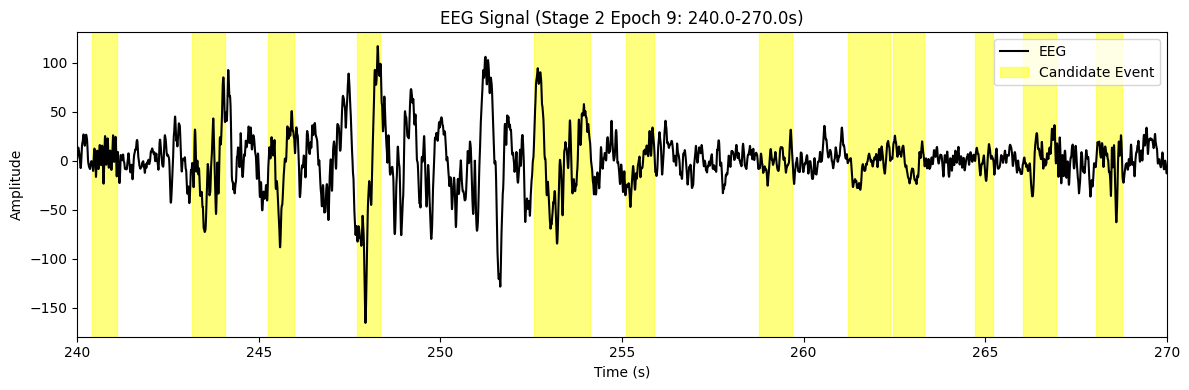

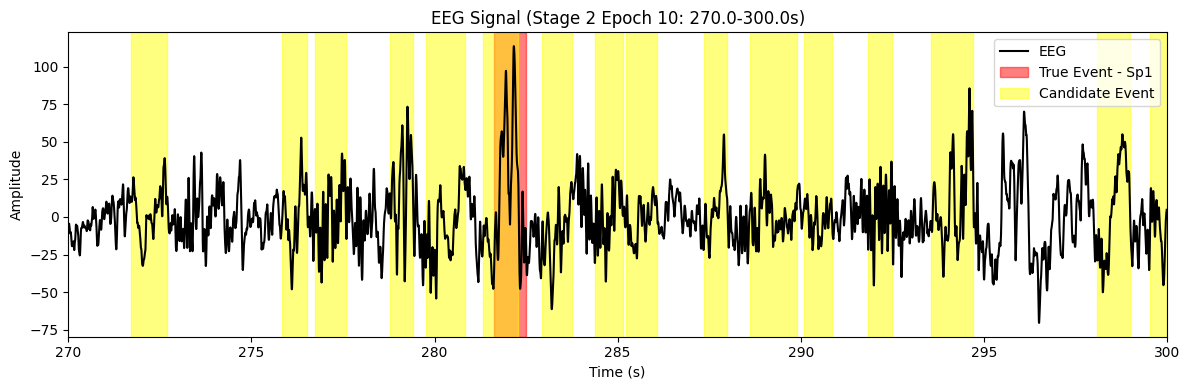

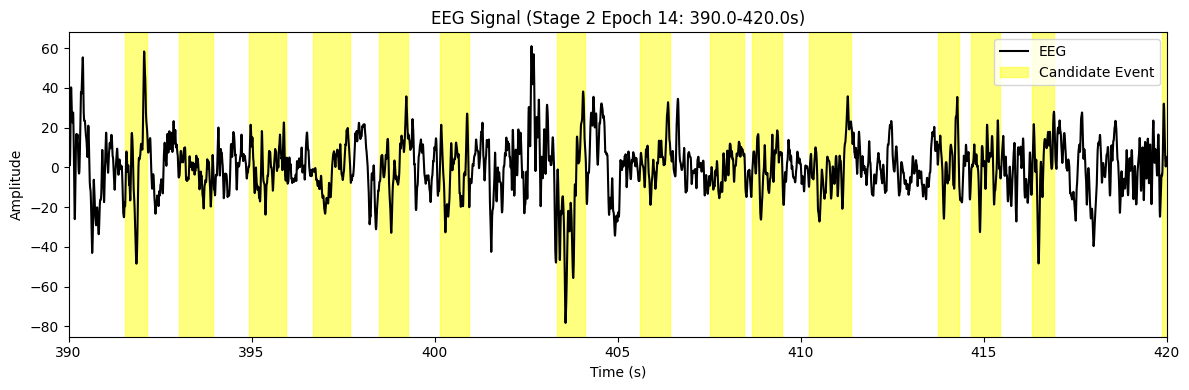

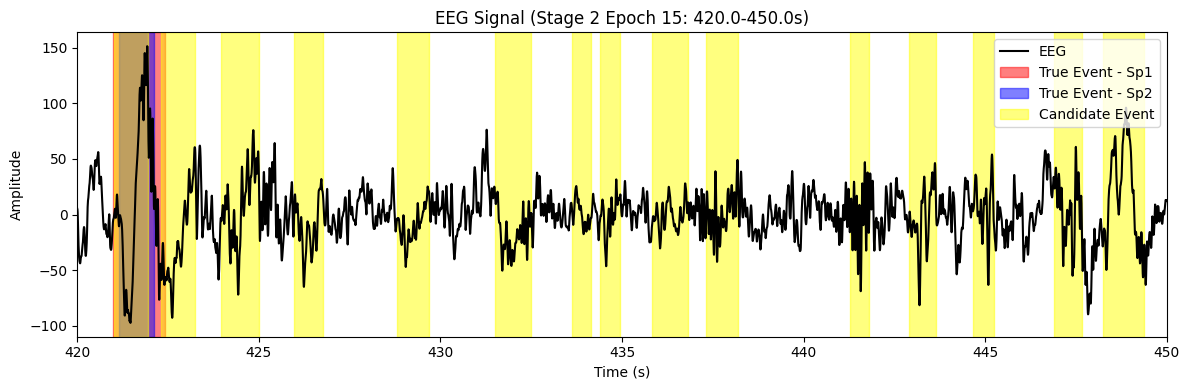

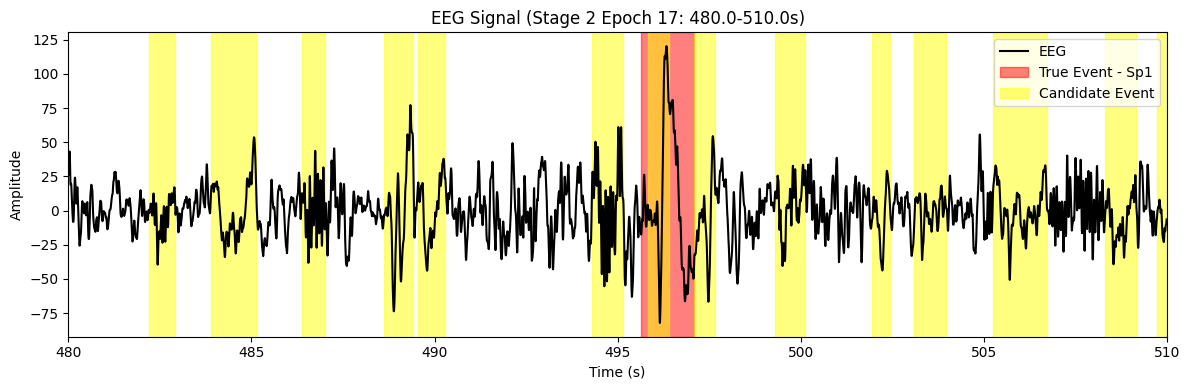

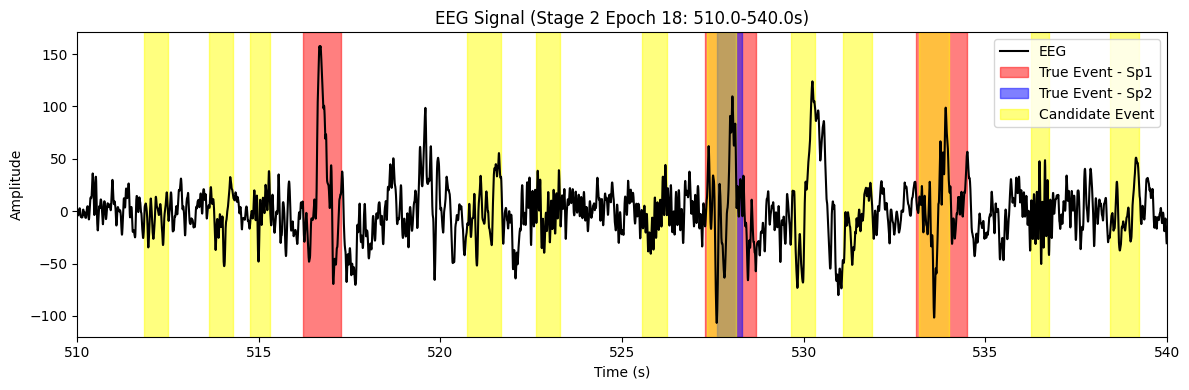

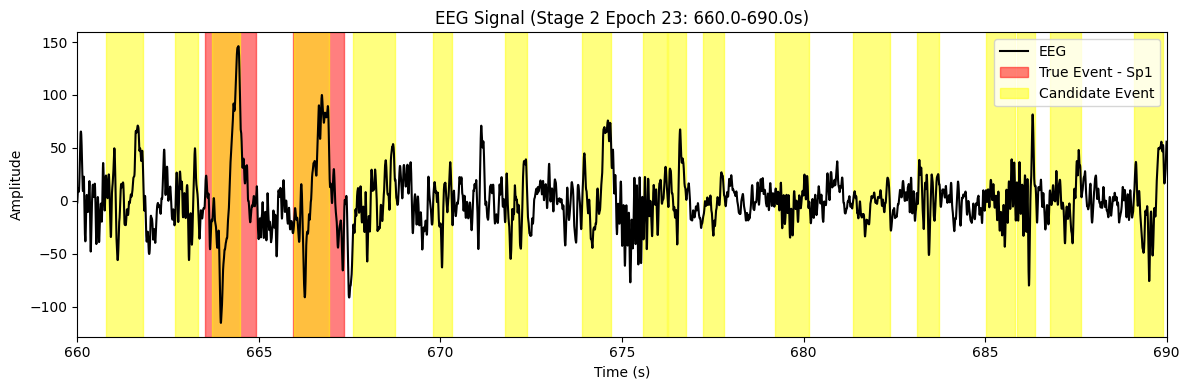

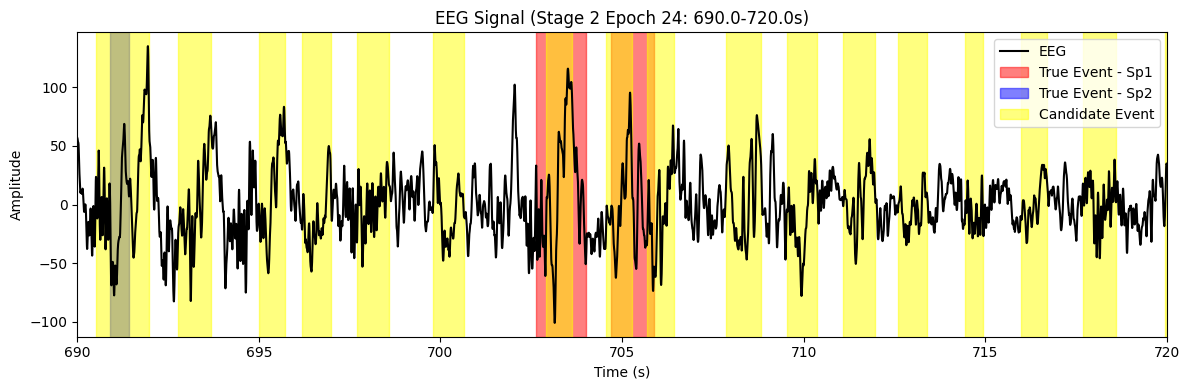

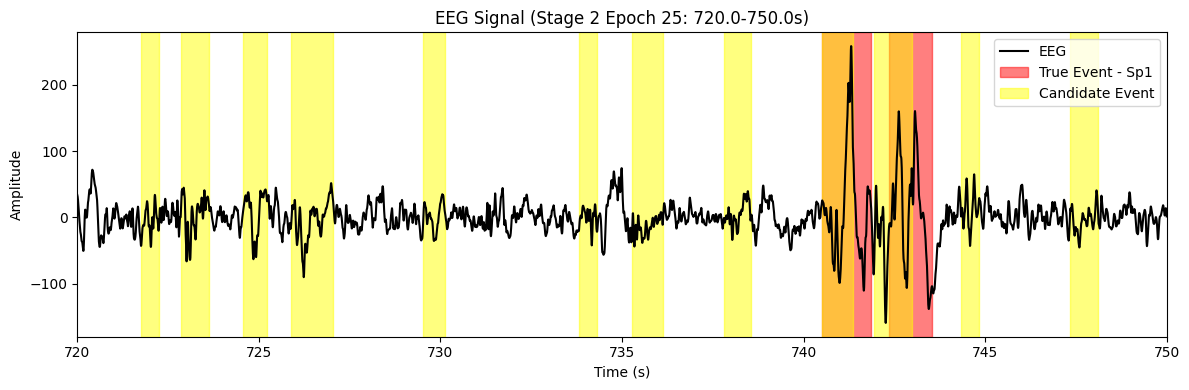

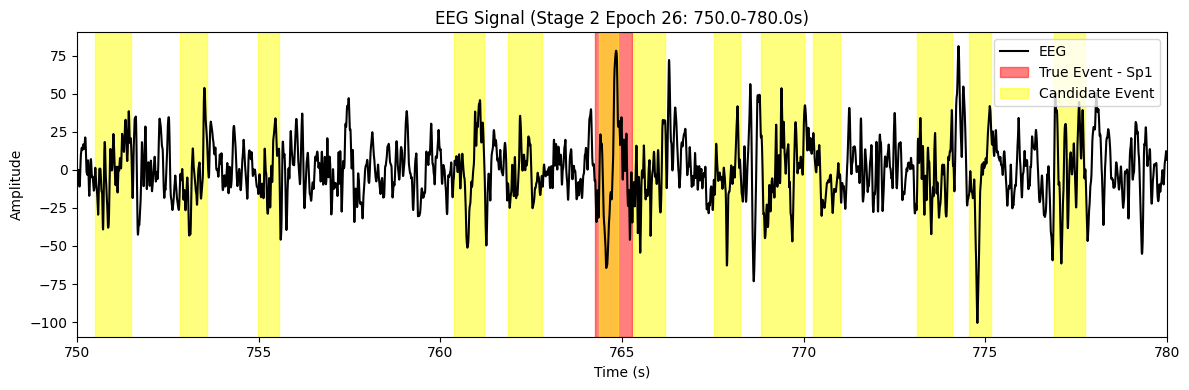

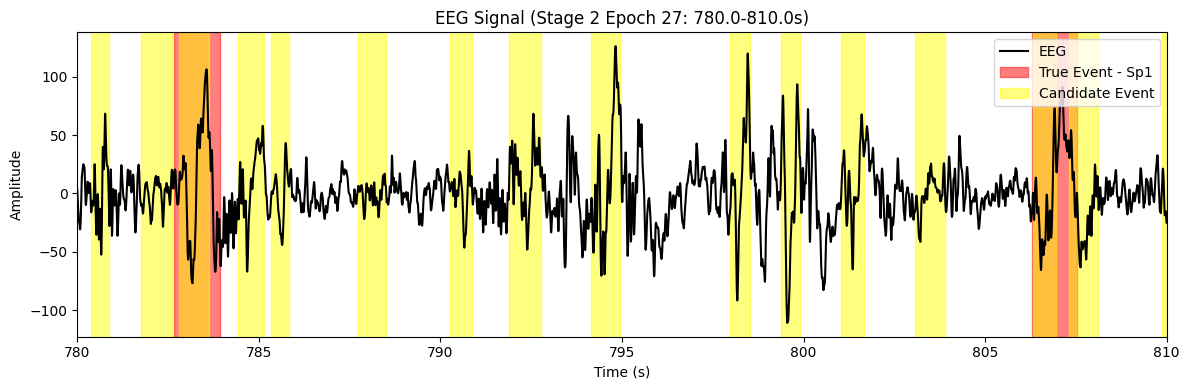

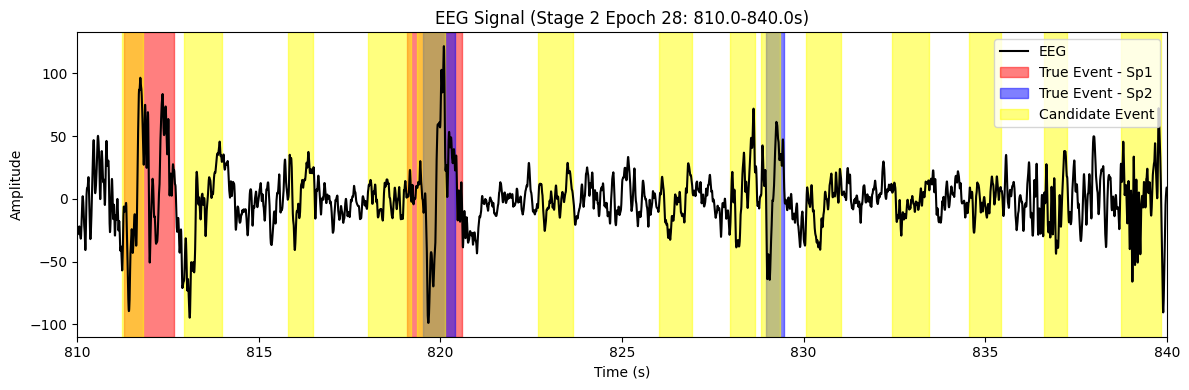

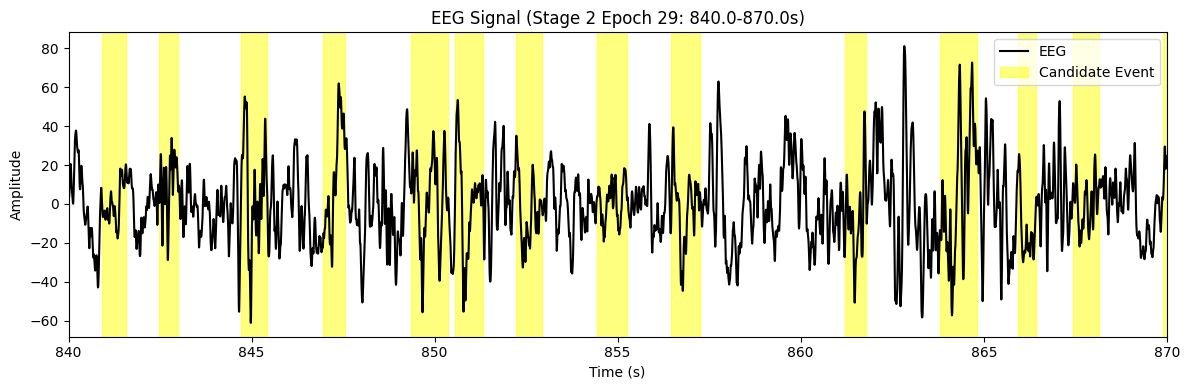

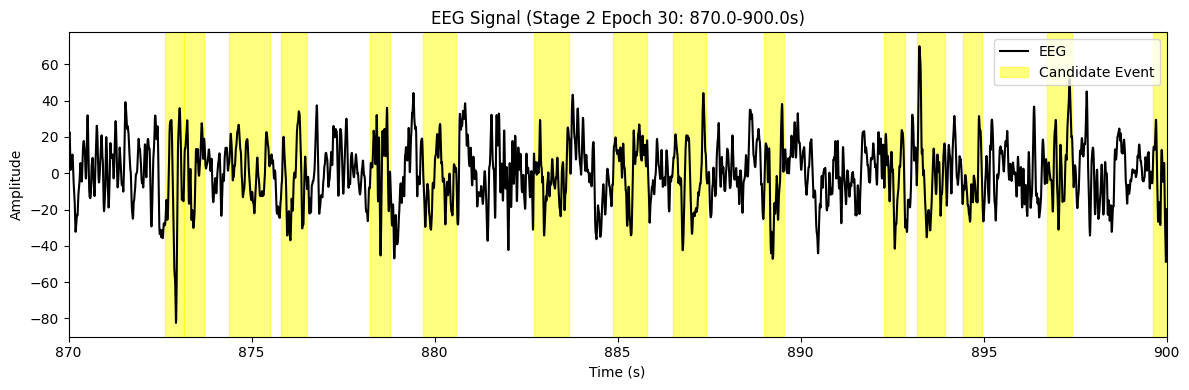

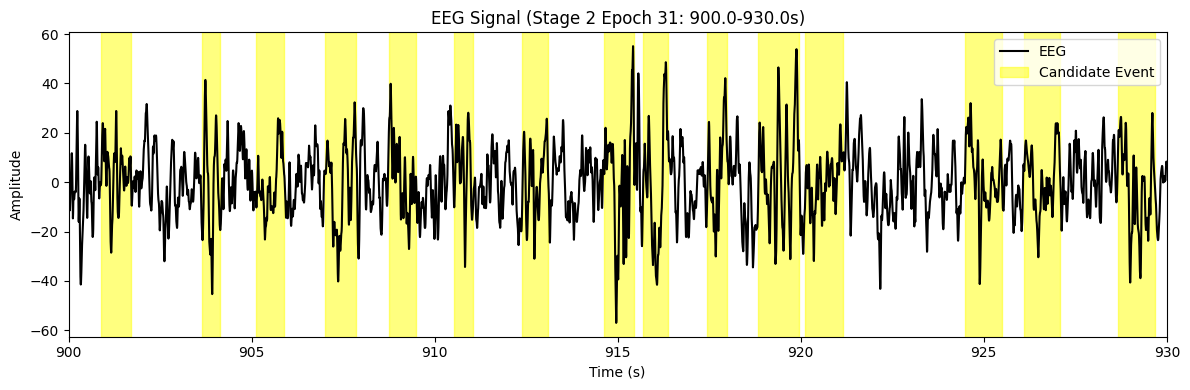

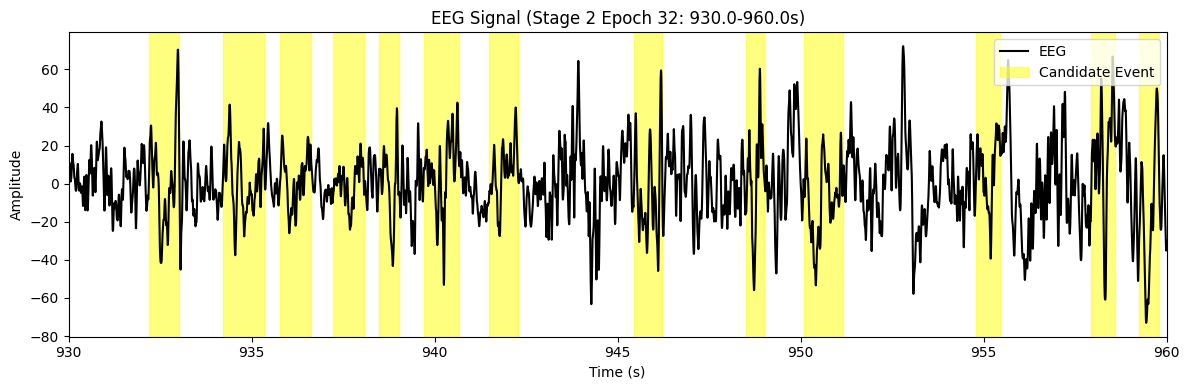

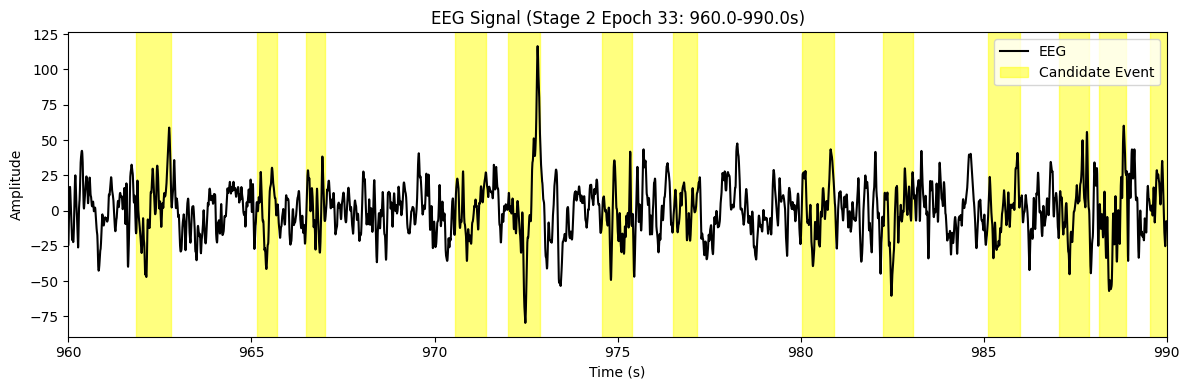

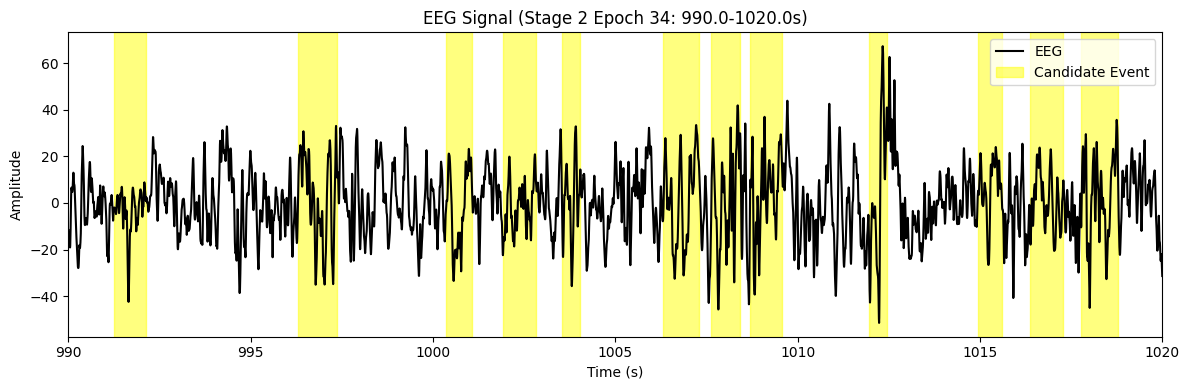

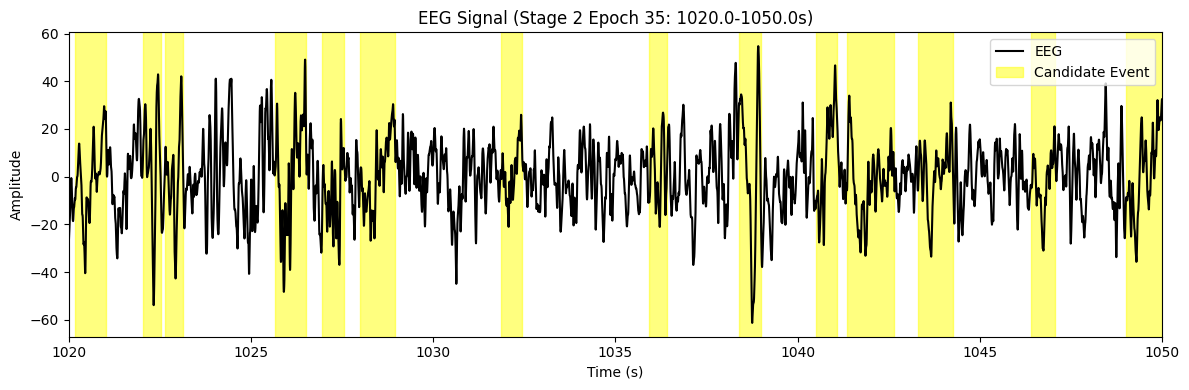

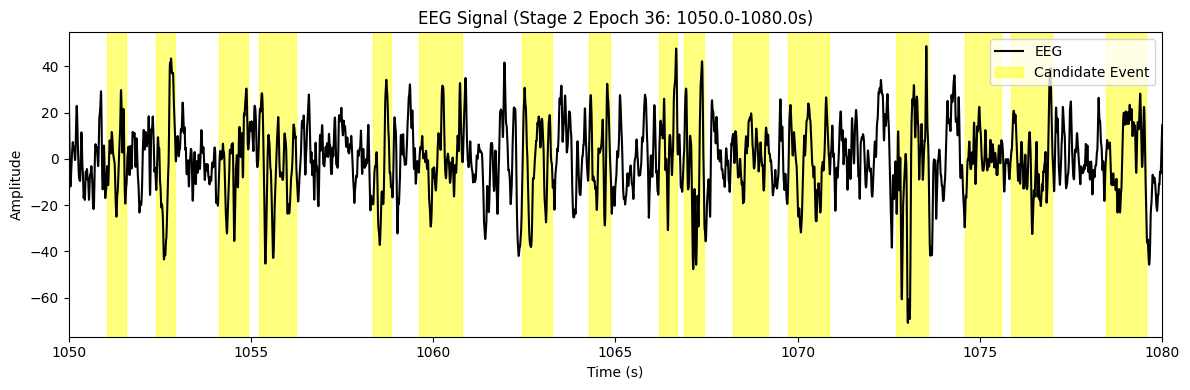

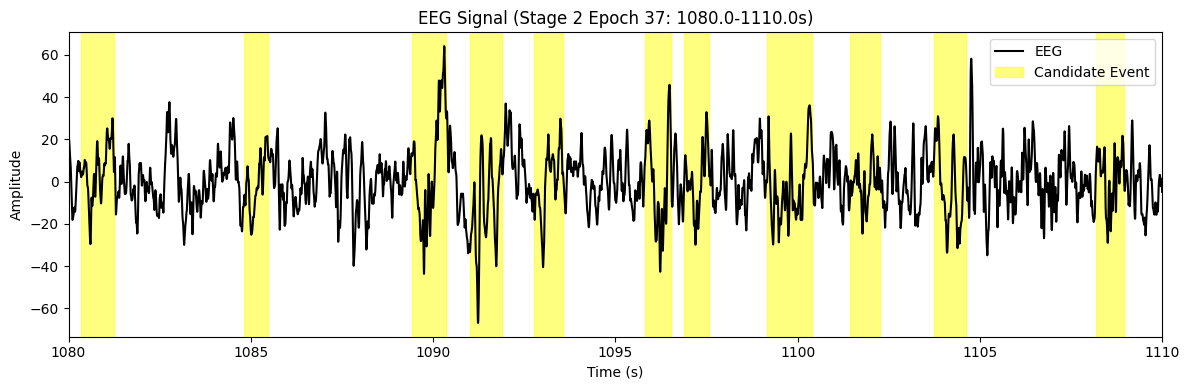

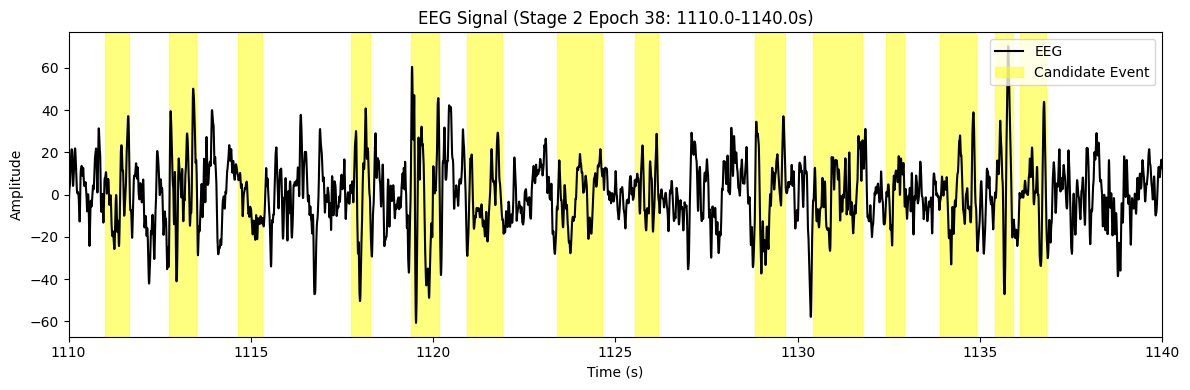

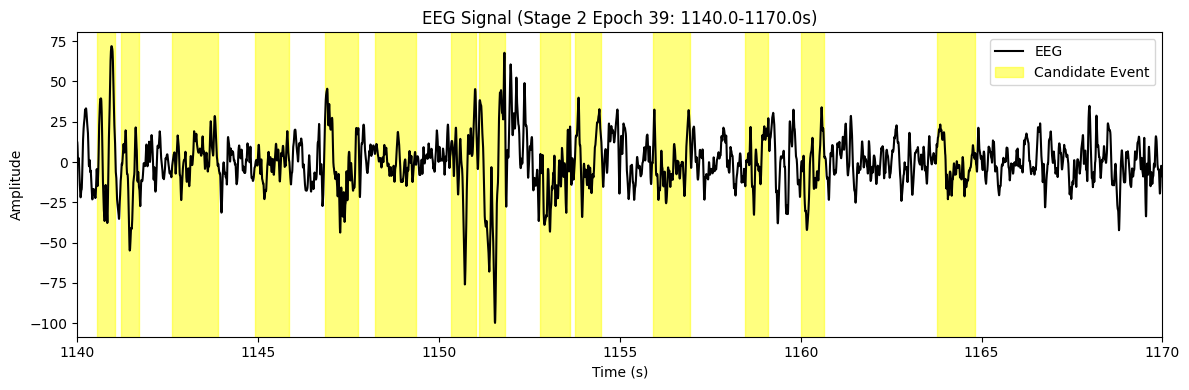

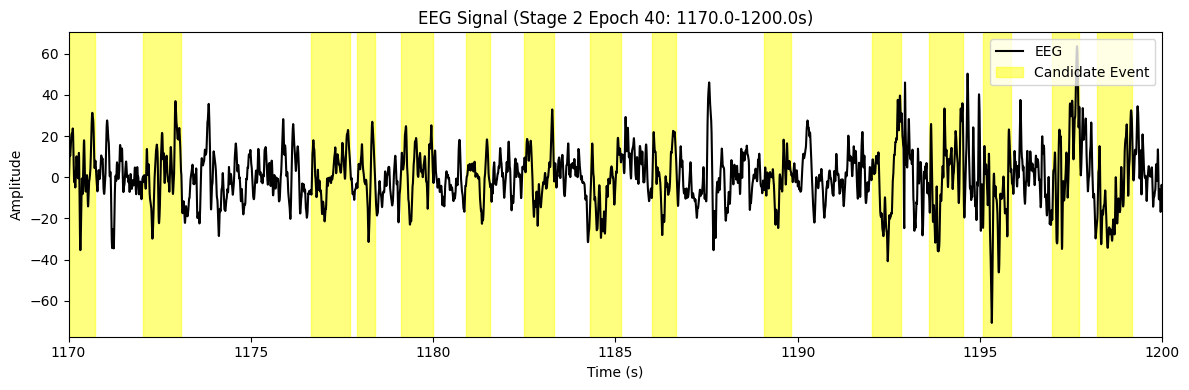

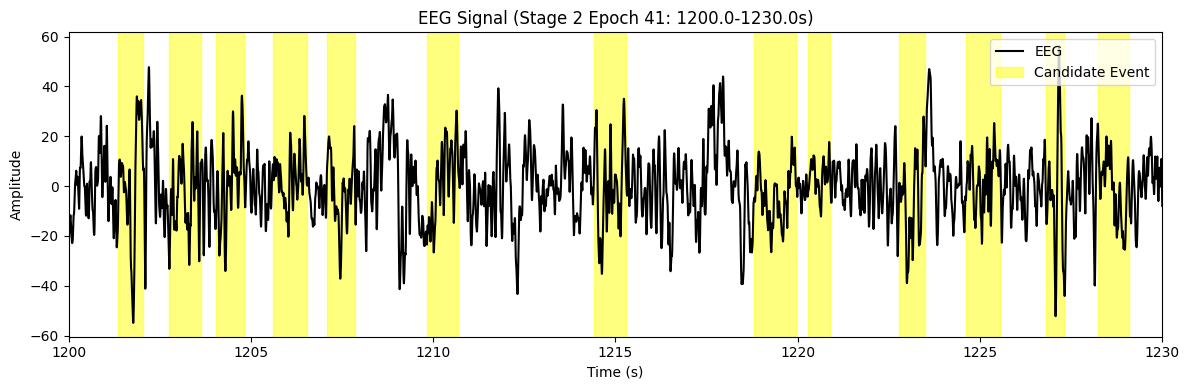

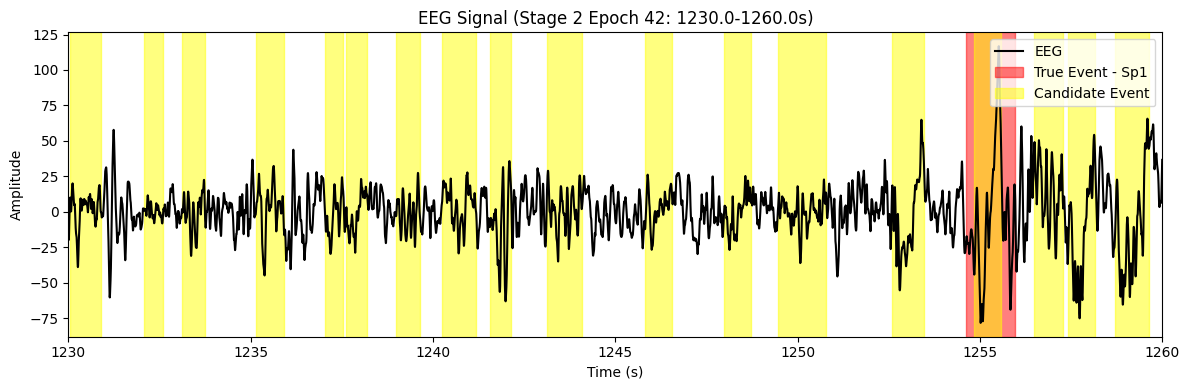

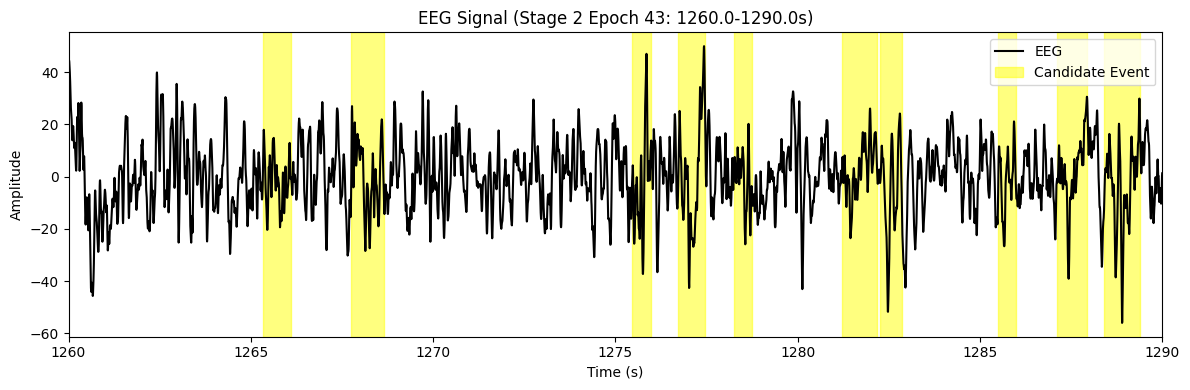

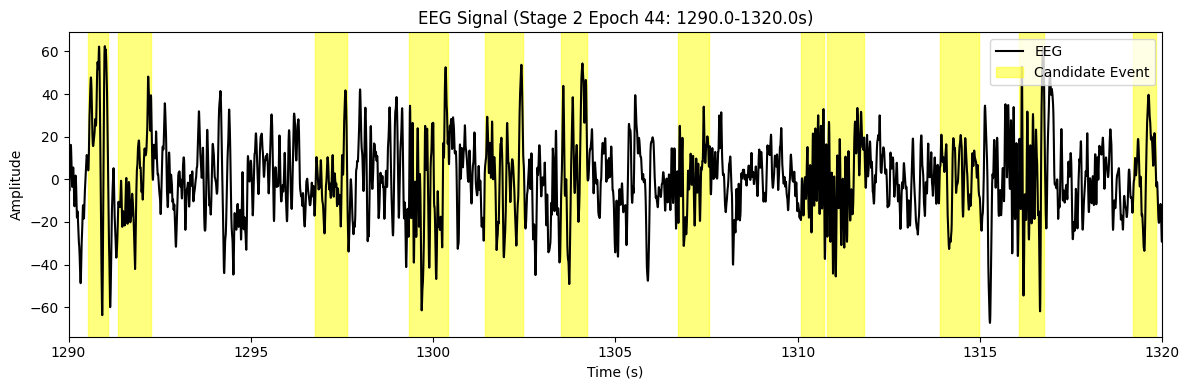

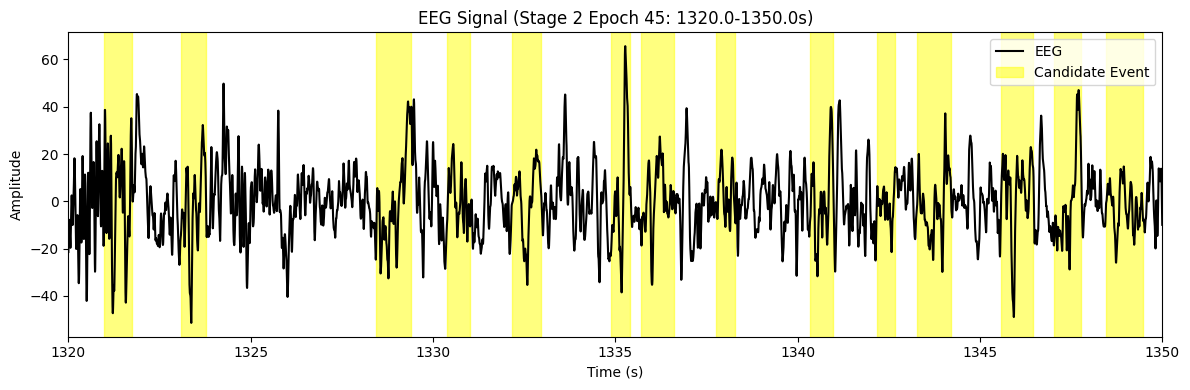

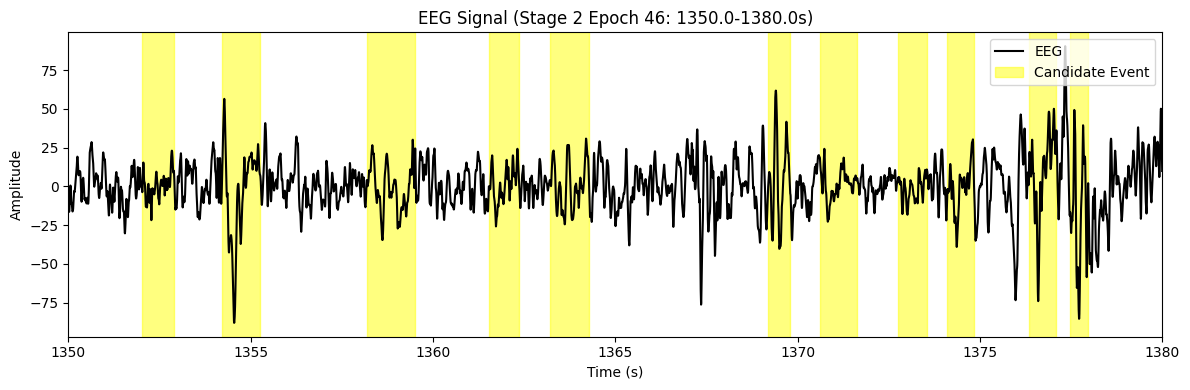

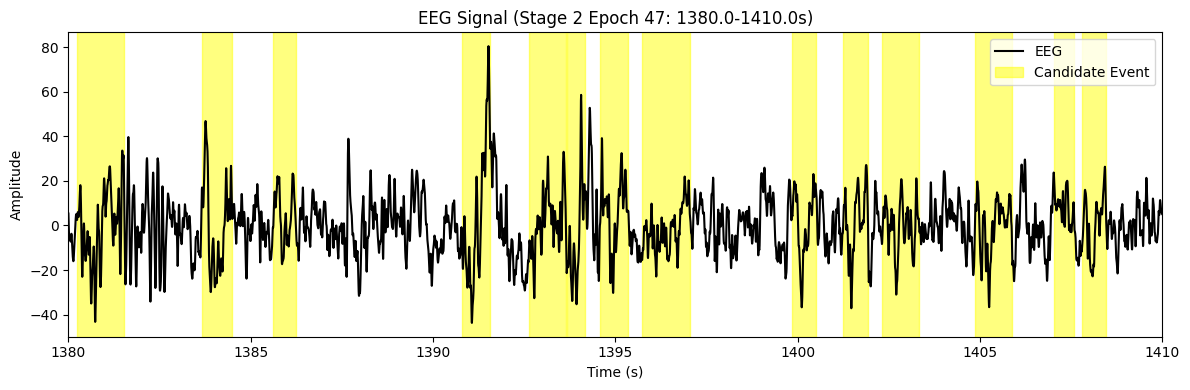

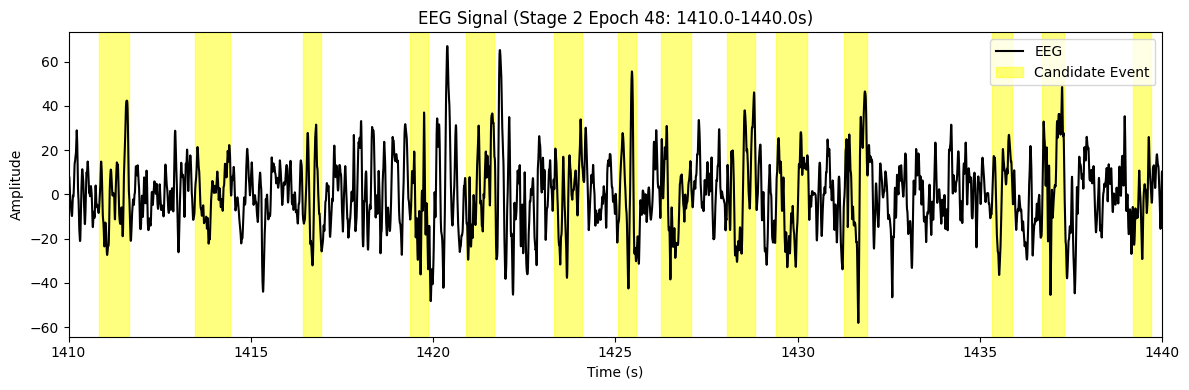

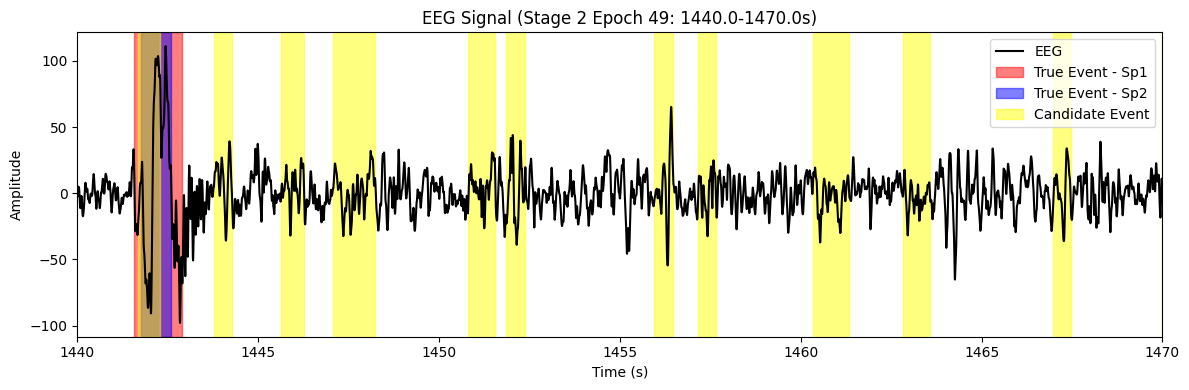

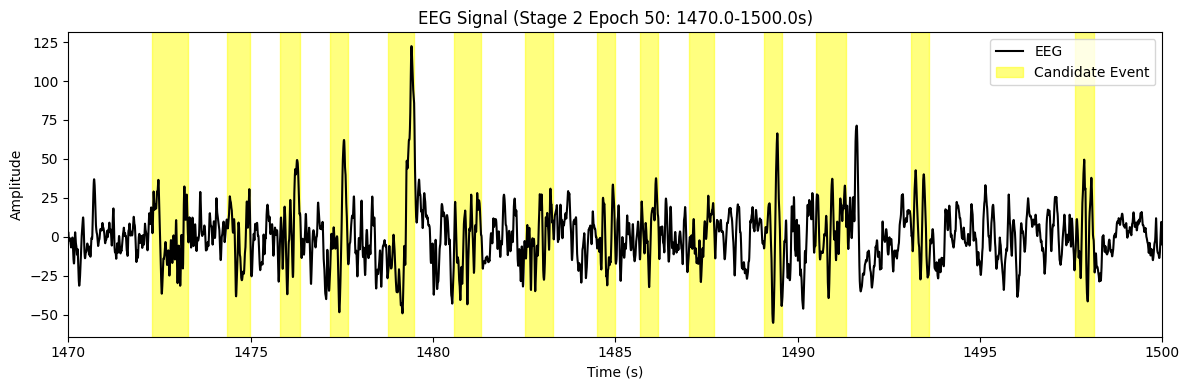

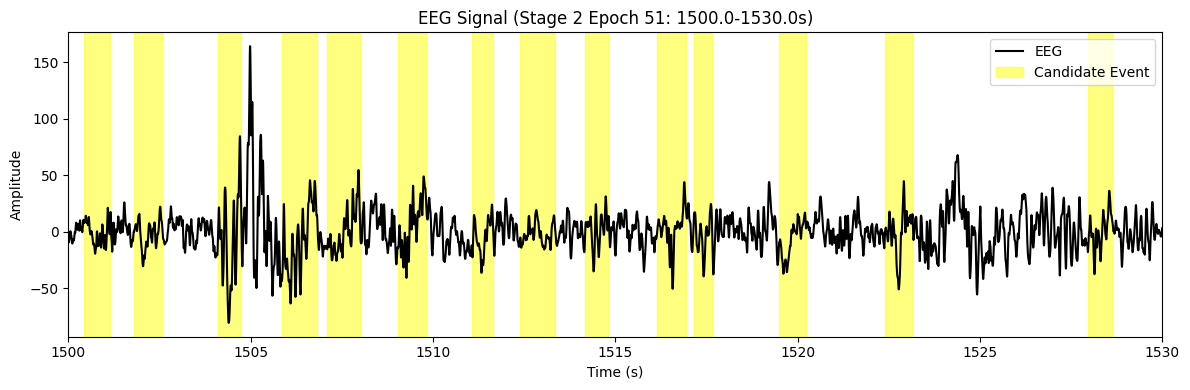

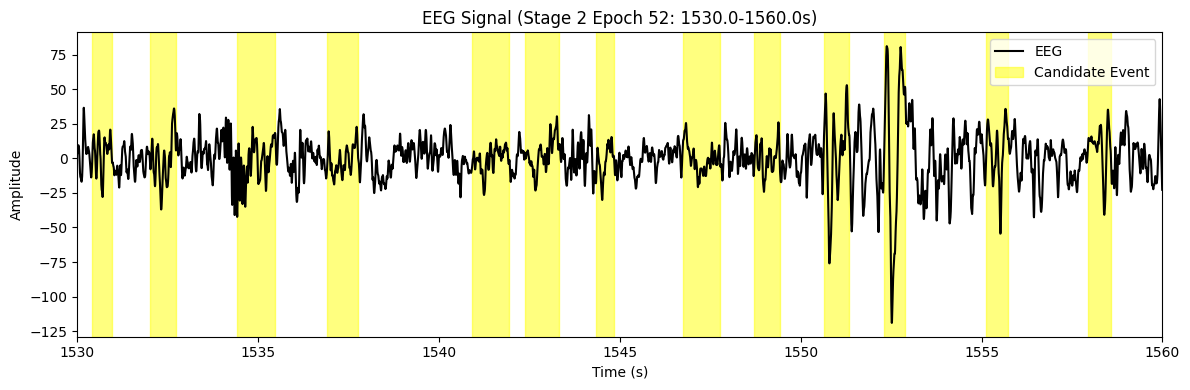

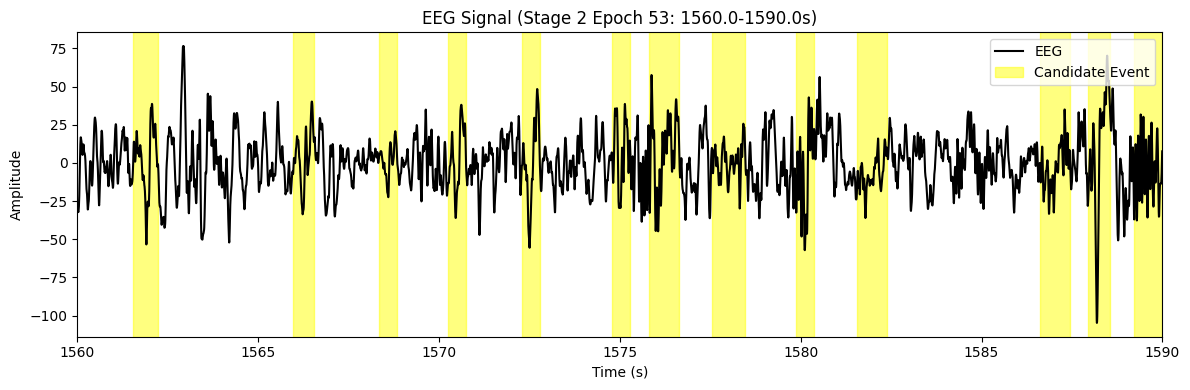

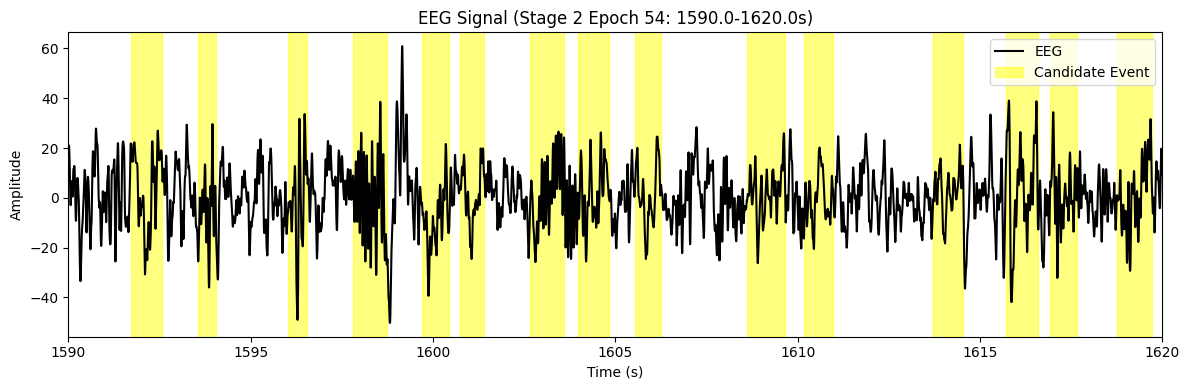

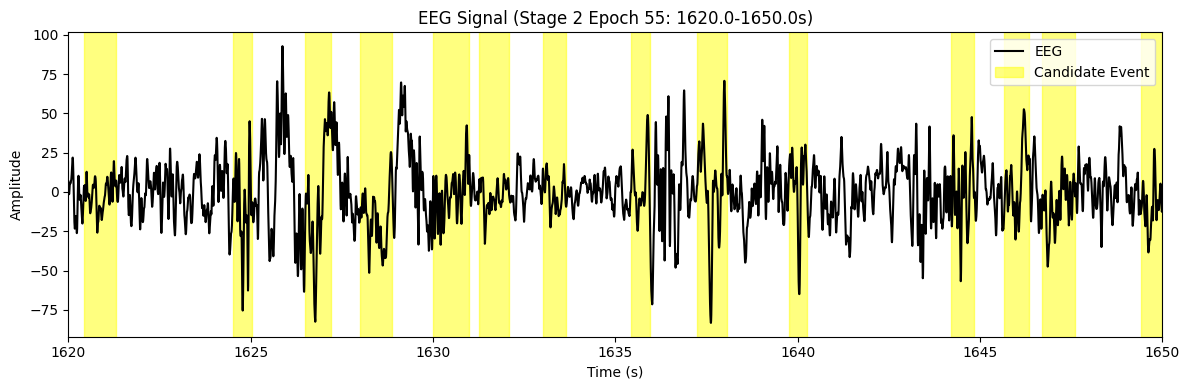

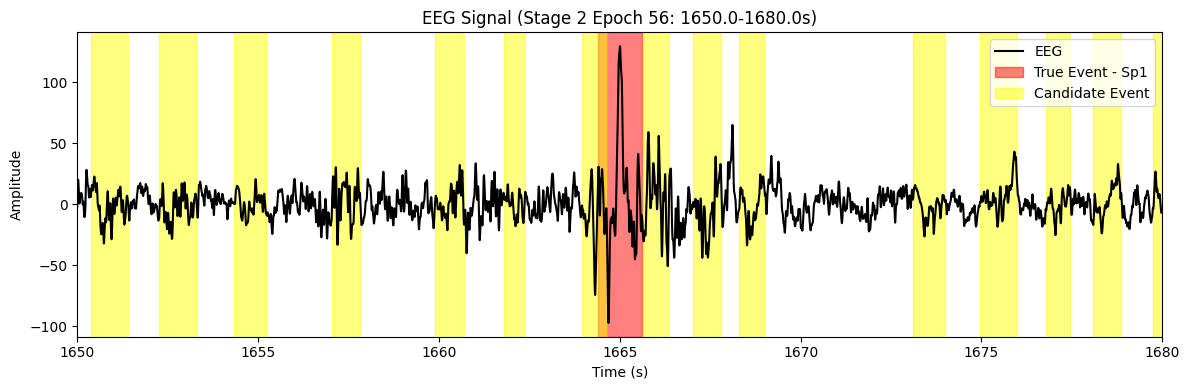

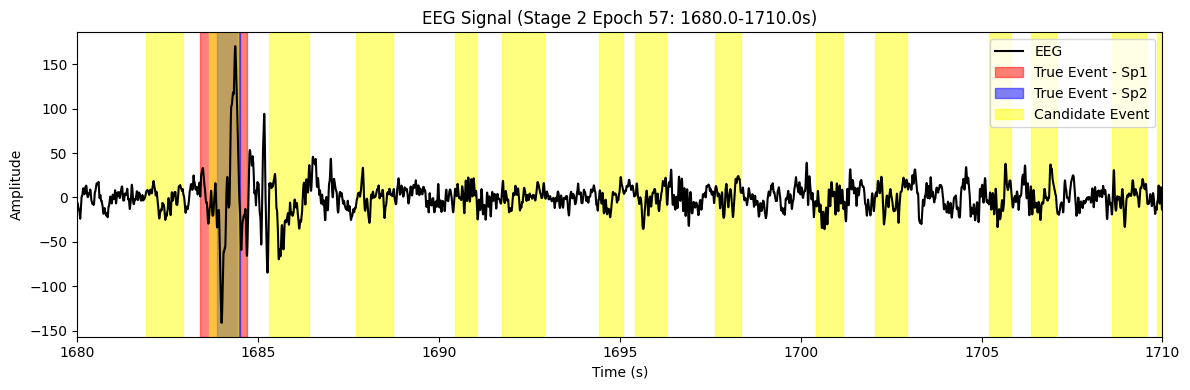

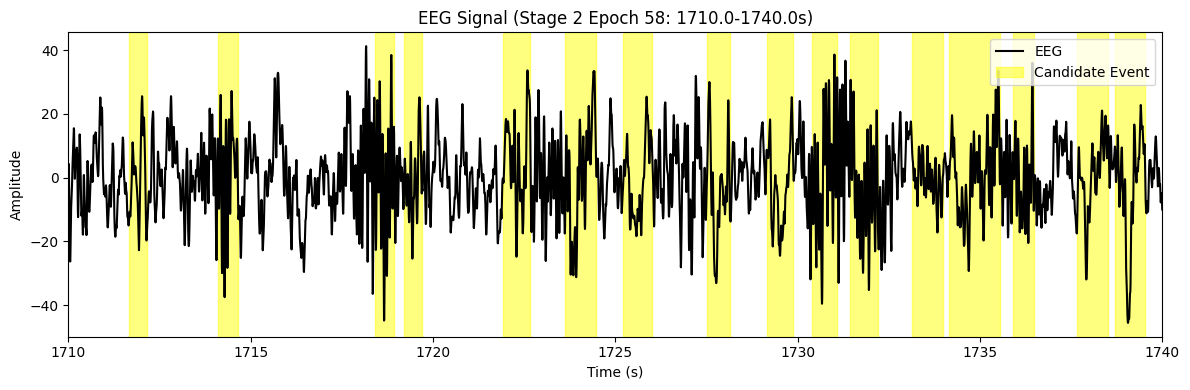

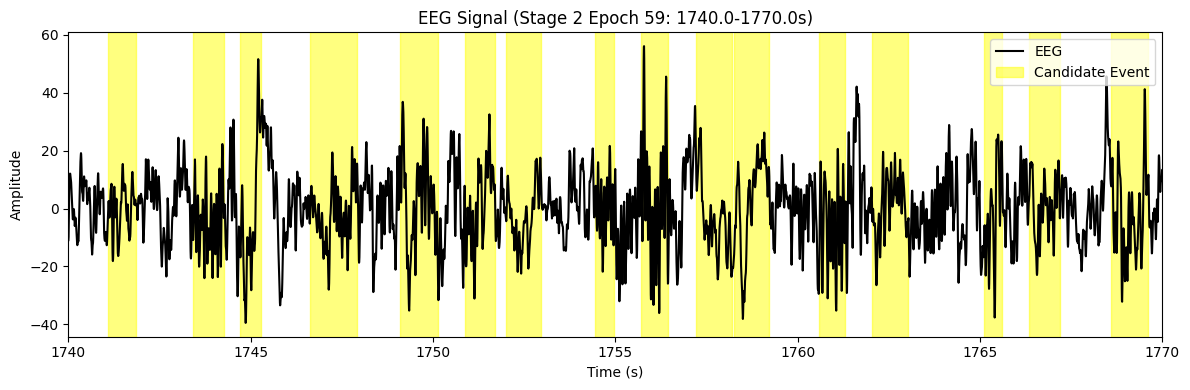

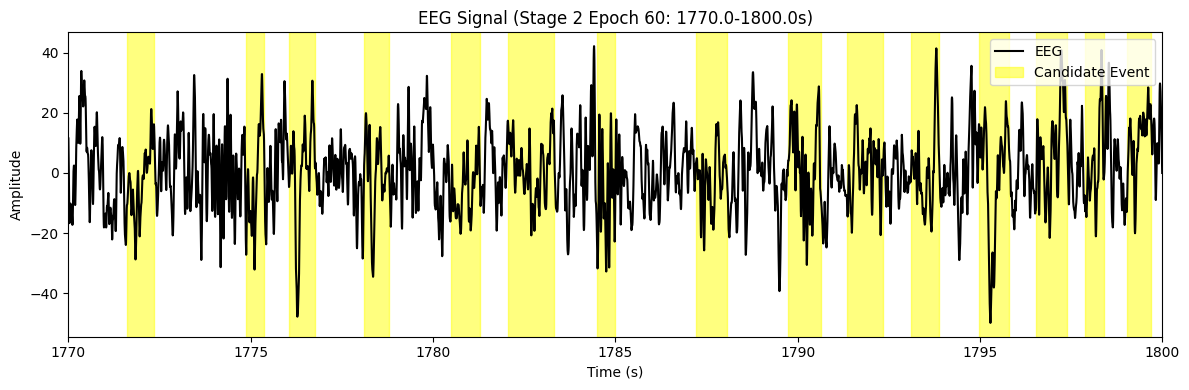

In [13]:
expert = 'expert1'
window = 2
subject_num = 1

if expert == 'expert1':
    list_of_experts = ['both', 'expert1']
    subjects = [4]#[i+1 for i in range(10)]
elif expert == 'expert2':
    list_of_experts = ['both', 'expert2']
    subjects = [i+1 for i in range(5)]
elif expert == 'any_both':
    list_of_experts = ['both', 'expert2', 'expert1']
    subjects = [i+1 for i in range(5)]
elif expert == 'both_same_time':
    list_of_experts = ['both']
    subjects = [i+1 for i in range(5)]


# Read annotation from experts
annot_file1 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring1_excerpt'+str(subject_num)+'.txt'
data = np.loadtxt(annot_file1, skiprows=1)
event_times1, durations1 = data[:, 0], data[:, 1]

if subject_num <= 5: #Specialist 2 only annotate from subj 1 to 5
    annot_file2 = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Visual_scoring2_excerpt'+str(subject_num)+'.txt'
    data = np.loadtxt(annot_file2, skiprows=1)
    event_times2, durations2 = data[:, 0], data[:, 1]
else:
    event_times2, durations2 = np.array([]), np.array([]) 

# Read annotations from DREAMS automatic algorithm
dreams_detection_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Automatic_detection_excerpt'+str(subject_num)+'.txt'
data = np.loadtxt(dreams_detection_file, skiprows=1)
predicted_event_times, predicted_durations = data[:, 0], data[:, 1]

# Read sleep scoring file
scoring_file_30s = r"C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\Hypnogram_excerpt"+str(subject_num)+"_30s_epoch.txt"
with open(scoring_file_30s, 'r') as f:
    lines = f.readlines()[1:]  # skip first line
    stages = np.array([int(line.strip()) for line in lines])

# Identify epochs with stage 2
stage_2_indices = np.where(stages == 2)[0]

# Assume each epoch is 30 seconds long
epoch_duration = 30  # seconds
time_stage_2 = stage_2_indices * epoch_duration

# Create binary indicator for plotting
indicator = np.zeros_like(stages, dtype=int)
indicator[stage_2_indices] = 1

# Read edf file
edf_file = r'C:\Users\ayvazquez\aylin\KC_detection_algorithm\data\The DREAMS Databases and Assessment Algorithm\excerpt'+ str(subject_num) +'.edf'
raw = mne.io.read_raw_edf(edf_file, preload=True)
channels = raw.info['ch_names']

# Filter only channel to use
raw_filtered = raw.copy().filter(l_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][0], h_freq=configuration.CUT_OFF_FREQUENCIES['eeg'][1], picks='CZ-A1')

# Get channel to detect candidates and sample frequency
x = raw_filtered.get_data(picks='CZ-A1').flatten()
fs = raw.info['sfreq']

# LOCALIZATOR - Get candidates
candidates = get_candidates(signal=x, path_scoring=scoring_file_30s , sfreq=fs, window_length=2)

labels, match_stats, expert1_annotations, expert2_annotations = label_candidates_and_count_matches(candidates,
                                                                                                    annot_file1,
                                                                                                    annot_file2,
                                                                                                    scoring_file_30s,
                                                                                                    subject_num)

events = []
for cand, lab in zip(candidates, labels):
    cand_event = get_KC_event(cand, x, sfreq=fs, window=2, timelocked2='center')[0].tolist()
    if lab in ['both', expert]:
        cand_lab = 1
    else:
        cand_lab = 0
    events.append(cand_event + [subject_num, cand_lab])

plot_eeg_with_events_and_candidates(
    x=x,
    fs=fs,
    candidates=candidates,
    event_times1=event_times1,
    durations1=durations1,
    event_times2=event_times2,
    durations2=durations2,
    #predicted_event_times=predicted_event_times, predicted_durations=predicted_durations,
    indicator=indicator  # only Stage 2 windows will be shown
)

## Detector

In [ ]:
df_overall.head()

In [ ]:
df_overall = df_overall.dropna()
df_overall['Flag'] = np.where(df_overall['Label'] == 'KC', 1, 0)

df_overall.head()

In [ ]:
subj_numKCs = df_overall[df_overall['Label'] == 'KC'].groupby('Subject').nunique()['sample1']

In [ ]:
df_overall[(df_overall['Subject'] == subject_num) & (df_overall['Label'] == 'noKC')].sample(5).index

In [ ]:
for numKCs, subject_num in zip(subj_numKCs, subj_numKCs.index):
    subject_num = int(subject_num)
    idxs_to_flag = df_overall[(df_overall['Subject'] == subject_num) & (df_overall['Label'] == 'noKC')].sample(numKCs).index
    df_overall.loc[idxs_to_flag, 'Flag'] = 1

In [ ]:
df_overall.groupby('Subject')['Flag'].value_counts()

In [ ]:
df_model = df_overall[df_overall['Flag'] == 1].reset_index()
df_model = df_model.drop(columns='index')

In [ ]:
y = df_model.copy()['Label']
X = df_model.drop(columns=['Label','Subject','Flag'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [ ]:
t = np.linspace(0,2,2*200)
plt.plot(t, np.mean(X.iloc[np.where(y == 'KC')], axis=0).values, label='KC')
plt.plot(t, np.mean(X.iloc[np.where(y == 'noKC')], axis=0).values, label='noKC')
plt.legend()
plt.show()

### Cross-validation

In [ ]:
scores_nus = []
nus = np.linspace(0.1,0.9,9*10)
for n in nus:
    score_nu = svm.NuSVC(nu=n, kernel='rbf').fit(X_train, y_train).score(X_test, y_test)
    scores_nus.append(score_nu)

plt.plot(nus, scores_nus)
plt.title('NuSVM Nu parameter comparison')
plt.ylabel('Accuracy')
plt.xlabel('Nu')
plt.show()

clf = svm.NuSVC(nu=nus[scores_nus.index(max(scores_nus))], kernel='rbf', gamma='scale')

for sc in ('accuracy','f1_macro','recall_macro'):
    print(sc)
    scores = cross_val_score(clf, X, y, cv=10, scoring=sc)
    print(round(scores.mean(),2), '+-', round(scores.std(),2))

In [ ]:
clf = svm.NuSVC(nu=nus[scores_nus.index(max(scores_nus))], kernel='rbf', gamma='scale', probability=True)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)

TP = int(cm[1, 1])
FP = int(cm[0, 1])
FN = int(cm[1, 0])
TN = int(cm[0, 0])

In [ ]:
similar_KC = X_test.iloc[np.where((clf.predict_proba(X_test)[:,0] >= 0.3) & (clf.predict_proba(X_test)[:,0] < 0.5) & (y_test == 'noKC'))]
similar_KC

In [ ]:
t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(similar_KC, axis=0), 'black', linewidth=3)
# for sim_KC in similar_KC.values:
#     plt.plot(t, sim_KC, alpha=0.5)
plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'KC')], axis=0).values, label='Predicted')
plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'KC')], axis=0).values, label='True')
plt.legend()
plt.show()

In [ ]:
t = np.linspace(0,2,2*200)
# plt.plot(t, np.mean(similar_KC, axis=0), 'black', linewidth=3)
# for sim_KC in similar_KC.values:
#     plt.plot(t, sim_KC, alpha=0.5)
plt.plot(t, np.mean(X_test.iloc[np.where(y_pred == 'noKC')], axis=0).values, label='Predicted')
plt.plot(t, np.mean(X_test.iloc[np.where(y_test == 'noKC')], axis=0).values, label='True')
plt.legend()
plt.show()

In [ ]:
max_nus = nus[scores_nus.index(max(scores_nus))]
max_nus = float(max_nus)
max_nus

### Stratified kFold

In [ ]:
l = len(df_overall) #number of training samples
l_pos = len(df_overall[df_overall['Label'] == 'KC']) #number of KC
l_neg = len(df_overall[df_overall['Label'] == 'noKC']) #number of noKC
nu_selected = min(l_pos/l,l_neg/l) * max_nus / 0.5
nu_selected

In [ ]:
y_overall = df_overall.copy()['Label']
X_overall = df_overall.drop(columns=['Label','Subject','Flag'])
X_overall_train, X_overall_test, y_overall_train, y_overall_test = train_test_split(X_overall, y_overall, test_size=0.2, random_state=10)

In [ ]:
X_overall = X_overall.reset_index()
X_overall = X_overall.drop(columns=['index'])
y_overall = y_overall.reset_index()
y_overall = y_overall.drop(columns=['index'])

In [ ]:
kf = StratifiedKFold(n_splits=10)

accuracy = []
m = ['precision', 'recall', 'f1-score']
metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
            'KC': {'precision': [], 'recall': [], 'f1-score': []}}
TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []

for i, (train_index, test_index) in enumerate(kf.split(X_overall, y_overall)):
    X_train, X_test = X_overall.loc[train_index], X_overall.loc[test_index]
    y_train, y_test = y_overall.loc[train_index], y_overall.loc[test_index]
    # print('Number of samples in train:', len(y_train))
    # print(y_train.value_counts())
    # print('Number of samples in test:', len(y_test))
    # print(y_test.value_counts())
    clf = svm.NuSVC(nu=0.04, kernel='rbf', gamma='scale')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    TP_avg.append(int(cm[0, 0]))
    FP_avg.append(int(cm[1, 0]))
    FN_avg.append(int(cm[0, 1]))
    TN_avg.append(int(cm[1, 1]))
    
    report = classification_report(y_test, y_pred, output_dict=True)
    for me in m:
        metrics['noKC'][me].append(report['noKC'][me])
        metrics['KC'][me].append(report['KC'][me])
    accuracy.append(report['accuracy'])

print()
for me in m:
    print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
    print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
    print()
print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
cm_num = np.array([[TP, FN],[FP, TN]])
cm_normalized_true = np.array([[TP/(TP + FP), FN/(FN + TN)],[FP/(TP + FP), TN/(FN + TN)]])
cm_normalized_pred = np.array([[TP/(TP + FN), FN/(TP + FN)],[FP/(FP + TN), TN/(TN + FP)]])

ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)

### Stratified Shuffle Split

In [ ]:
sh = StratifiedShuffleSplit(n_splits=10, test_size=0.2)

accuracy = []
m = ['precision', 'recall', 'f1-score']
metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
            'KC': {'precision': [], 'recall': [], 'f1-score': []}}
TP_avg, FP_avg, FN_avg, TN_avg = [], [], [], []

for i, (train_index, test_index) in enumerate(sh.split(X_overall, y_overall)):
    X_train, X_test = X_overall.loc[train_index], X_overall.loc[test_index]
    y_train, y_test = y_overall.loc[train_index], y_overall.loc[test_index]

    # print('Number of samples in train:', len(y_train))
    # print(y_train.value_counts())
    # print('Number of samples in test:', len(y_test))
    # print(y_test.value_counts())

    clf = svm.NuSVC(nu=nu_selected, kernel='rbf', gamma='scale')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    TP_avg.append(int(cm[0, 0]))
    FP_avg.append(int(cm[1, 0]))
    FN_avg.append(int(cm[0, 1]))
    TN_avg.append(int(cm[1, 1]))

    report = classification_report(y_test, y_pred, output_dict=True)
    for me in m:
        metrics['noKC'][me].append(report['noKC'][me])
        metrics['KC'][me].append(report['KC'][me])
    accuracy.append(report['accuracy'])

print()
for me in m:
    print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
    print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
    print()
print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

TP, FP, FN, TN = float(np.mean(TP_avg)), float(np.mean(FP_avg)), float(np.mean(FN_avg)), float(np.mean(TN_avg))
cm_num = np.array([[TP, FN],[FP, TN]])
cm_normalized_true = np.array([[TP/(TP + FP), FN/(FN + TN)],[FP/(TP + FP), TN/(FN + TN)]])
cm_normalized_pred = np.array([[TP/(TP + FN), FN/(TP + FN)],[FP/(FP + TN), TN/(TN + FP)]])

ConfusionMatrixDisplay(cm_num, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False, values_format='.1f')
ConfusionMatrixDisplay(cm_normalized_true, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)
ConfusionMatrixDisplay(cm_normalized_pred, display_labels=clf.classes_ ).plot(cmap='Blues', colorbar=False)

### Group KFold

In [ ]:
groups = df_overall['Subject'].values

gk = GroupKFold(n_splits=5)

accuracy = []
m = ['precision', 'recall', 'f1-score']
metrics = {'noKC': {'precision': [], 'recall': [], 'f1-score': []},
            'KC': {'precision': [], 'recall': [], 'f1-score': []}}

for i, (train_index, test_index) in enumerate(gk.split(X_overall, y_overall, groups=groups)):
    X_train, X_test = X_overall.loc[train_index], X_overall.loc[test_index]
    y_train, y_test = y_overall.loc[train_index], y_overall.loc[test_index]

    # print('Number of samples in train:', len(y_train))
    # print(y_train.value_counts())
    # print('Number of samples in test:', len(y_test))
    # print(y_test.value_counts())

    clf = svm.NuSVC(nu=nu_selected, kernel='rbf', gamma='scale')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)

    for me in m:
        metrics['noKC'][me].append(report['noKC'][me])
        metrics['KC'][me].append(report['KC'][me])
    accuracy.append(report['accuracy'])

print()
for me in m:
    print(f'{me.upper()} noKC - {round(np.mean(metrics["noKC"][me]),3)} +- {round(np.std(metrics["noKC"][me]),3)}')
    print(f'{me.upper()} KC - {round(np.mean(metrics["KC"][me]),3)} +- {round(np.std(metrics["KC"][me]),3)}')
    print()
print(f"Accuracy: {round(np.mean(accuracy),3)} +- {round(np.std(accuracy),3)}")

## Test no flag

In [ ]:
clf_selected.fit(X.drop(columns=['index']), y)

In [ ]:
df_model = df_overall[df_overall['Flag'] == 0]

In [ ]:
print(int(sum(clf_selected.predict(df_model.drop(columns=['Label','Subject','Flag'])))), 'out of', len(df_model))
print(round(sum(clf_selected.predict(df_model.drop(columns=['Label','Subject','Flag'])))/len(df_model),4)*100,r'%')